## Library Import

In [180]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.metrics import r2_score
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

## Basic Model Creation 

In [181]:
# Assumes: import pandas as pd, numpy as np, statsmodels.api as sm

def variable_pd_analysis(
    df,
    var_names,
    target='default_12m',
    date_col='stmt_date',
    combined=False,
    cluster_by=None,     # e.g., 'id' to cluster SEs by firm
    drop_na='pairwise',  # 'pairwise' (per var) | 'listwise' (same rows for all vars)
    combined_only=False
):
    """
    Diagnostic PD logit: univariate pooled effects (no year controls), yearly stability by grouping,
    and optional combined model (also without year dummies). Prints summaries; returns a dict of results.

    Notes:
      - NO year fixed effects are included anywhere.
      - __year__ is computed only for the 'yearly stability' reporting (grouping), not as a regressor.
    """

    # ---- normalize inputs ----
    var_list = [var_names] if isinstance(var_names, str) else list(var_names)
    if drop_na not in ('pairwise', 'listwise'):
        raise ValueError("drop_na must be 'pairwise' or 'listwise'")

    df = df.copy()
    # Kept only for grouping in yearly stability (not used in regressions)
    df['__year__'] = pd.to_datetime(df[date_col], errors='coerce').dt.year

    # ---- helpers ----
    def _fit_logit(endog, exog, groups=None, disp=0):
        model = sm.Logit(endog, exog)
        if groups is not None:
            return model.fit(disp=disp, cov_type='cluster', cov_kwds={'groups': groups})
        else:
            return model.fit(disp=disp, cov_type='HC1')

    def _is_binary_series(s: pd.Series) -> bool:
        u = s.dropna().unique()
        if len(u) == 0:
            return False
        return set(np.unique(u)).issubset({0, 1})

    def _margeff_univariate(result, data, var_name):
        # treat dummies as discrete 0->1; continuous as derivative
        is_bin = _is_binary_series(data[var_name])
        return result.get_margeff(at='overall', method='dydx', dummy=is_bin)

    def _margeff_combined(result, d_all, var_list):
        """
        Align dummy flags to exog order (excluding const). Only original predictors appear.
        """
        exog_names = [n for n in result.model.exog_names if n != 'const']
        dummy_flags = [(n in var_list) and _is_binary_series(d_all[n]) for n in exog_names]
        return result.get_margeff(at='overall', method='dydx', dummy=dummy_flags)

    # ---- prepare listwise dataset (once) if requested ----
    d_listwise = None
    if drop_na == 'listwise':
        base_cols = [target] + var_list + ([cluster_by] if cluster_by else []) + ['__year__']
        d_listwise = df[base_cols].dropna().copy()

    results = {
        'univariate': {},
        'univariate_yearfe': {},  # kept for compatibility; will remain empty
        'yearly': {},
        'combined': None,
        'combined_margeff': None,
        'corr_combined': None
    }

    # ===================== UNIVARIATE (pooled, no year controls) ======================
    if not combined_only:
        for var_name in var_list:
            print(f"\n\n================  {var_name}  ================\n")

            # choose sample
            if drop_na == 'pairwise':
                use_cols = [target, var_name] + ([cluster_by] if cluster_by else []) + ['__year__']
                d = df[use_cols].dropna().copy()
            else:
                keep_cols = [target, var_name] + ([cluster_by] if cluster_by else []) + ['__year__']
                d = d_listwise[keep_cols].copy()

            if d.empty or d[target].nunique() < 2:
                print(f"[WARN] No usable data after NA-drop for {var_name}. Skipping.")
                continue

            y = d[target].astype(float)
            X = sm.add_constant(d[[var_name]].astype(float), has_constant='add')
            groups = d[cluster_by] if cluster_by is not None else None

            # pooled (NO year FE)
            print(f"=== Logistic Regression for {var_name} (pooled, no year FE) ===\n")
            res = _fit_logit(y, X, groups=groups)
            print(res.summary())
            results['univariate'][var_name] = res

            # AME
            try:
                marg = _margeff_univariate(res, d, var_name)
                print("\nMarginal Effects (Average, overall):\n")
                print(marg.summary())
            except Exception as e:
                print(f"\n[WARN] Marginal effects failed for {var_name}: {e}")

            # yearly stability (grouping only)
            print(f"\n=== Yearly Stability for {var_name} (no year FE; separate yearly fits) ===")
            yearly_stats = []
            for yr, block in d.groupby('__year__'):
                try:
                    if block[var_name].notna().sum() > 1 and block[target].nunique() == 2:
                        y_yr = block[target].astype(float)
                        X_yr = sm.add_constant(block[[var_name]].astype(float), has_constant='add')
                        g_yr = block[cluster_by] if cluster_by is not None else None
                        res_yr = _fit_logit(y_yr, X_yr, groups=g_yr, disp=0)
                        coef = float(res_yr.params.get(var_name, np.nan))
                        pval = float(res_yr.pvalues.get(var_name, np.nan))
                        print(f"{int(yr)}: coef={coef:.5f}, p={pval:.3e}")
                        yearly_stats.append((int(yr), coef, pval))
                    else:
                        print(f"{int(yr)}: model skipped (insufficient variation).")
                except Exception as e:
                    print(f"{int(yr)}: model failed → {e}")
            results['yearly'][var_name] = yearly_stats

    # ===================== COMBINED (no year controls) ======================
    if combined and len(var_list) > 1:
        print("\n\n================  COMBINED MULTIVARIATE MODEL  ================\n")

        # consistent sample across ALL variables
        base_cols = [target] + var_list + ([cluster_by] if cluster_by else []) + ['__year__']
        d_all = (df[base_cols].dropna().copy()
                 if drop_na == 'pairwise' else d_listwise.copy())

        if d_all.empty or d_all[target].nunique() < 2:
            print("[WARN] No usable data after NA-drop for combined model. Skipping.")
            return results

        y_all = d_all[target].astype(float)
        X_all = sm.add_constant(d_all[var_list].astype(float), has_constant='add')
        groups_all = d_all[cluster_by] if cluster_by is not None else None

        print("=== Logistic Regression (all variables, no year FE) ===\n")
        res_all = _fit_logit(y_all, X_all, groups=groups_all)
        print(res_all.summary())
        results['combined'] = res_all

        # AME aligned to exog order
        try:
            marg_all = _margeff_combined(res_all, d_all, var_list)
            print("\nMarginal Effects at the Overall (combined):\n")
            print(marg_all.summary())
            results['combined_margeff'] = marg_all
        except Exception as e:
            print(f"\n[WARN] Marginal effects (combined) failed: {e}")

        # simple collinearity hint
        try:
            corr = d_all[var_list].corr()
            print("\nPairwise correlation among predictors (combined):\n")
            print(corr)
            results['corr_combined'] = corr
        except Exception as e:
            print(f"\n[WARN] Correlation matrix failed: {e}")

    return results

## Reading Data

In [182]:
df = pd.read_csv("data/train-2025.csv", low_memory=False)

## Creating Default Flag

In [183]:
# Parse dates
df["stmt_date"] = pd.to_datetime(df["stmt_date"], errors="coerce")
df["def_date"]  = pd.to_datetime(df["def_date"],  errors="coerce")

In [184]:

# Ensure datetimes
df["stmt_date"] = pd.to_datetime(df["stmt_date"], errors="coerce")
df["def_date"]  = pd.to_datetime(df["def_date"],  errors="coerce")

# Params you can tune
LAG_MONTHS = 4          # reporting lag (e.g., 12/31/Y becomes usable ~ 4/30/Y+1)
HORIZON_MONTHS = 12     # prediction horizon
START_INCL, END_INCL = True, True  # window edge inclusivity

# 1) Availability date = when the statement becomes usable (prevents look-ahead)
df["avail_date"] = df["stmt_date"] + pd.DateOffset(months=LAG_MONTHS)

# 2) Prediction window [pred_start, pred_end]
df["pred_start"] = df["avail_date"]
df["pred_end"]   = df["avail_date"] + pd.DateOffset(months=HORIZON_MONTHS)

# 3) First default per firm (so we can drop post-default rows and mark pre-window defaults)
first_def = (
    df.loc[df["def_date"].notna(), ["id", "def_date"]]
      .groupby("id", as_index=False)["def_date"].min()
      .rename(columns={"def_date": "first_def"})
)
df = df.merge(first_def, on="id", how="left")

# 4) Build label without leakage
# Initialize as 0 (survived the window)
y = pd.Series(0, index=df.index, dtype="Int64")

# Unknown if statement missing
unknown_stmt = df["stmt_date"].isna()
y[unknown_stmt] = pd.NA

# Already defaulted before info was available → cannot use this row (set NA so you can drop it for training)
already_defaulted = df["first_def"].notna() & (df["first_def"] < df["pred_start"])
y[already_defaulted] = pd.NA

# Default within the prediction window → 1
has_def = df["def_date"].notna()
if START_INCL and END_INCL:
    in_win = has_def & (df["def_date"] >= df["pred_start"]) & (df["def_date"] <= df["pred_end"])
elif START_INCL and (not END_INCL):
    in_win = has_def & (df["def_date"] >= df["pred_start"]) & (df["def_date"] <  df["pred_end"])
elif (not START_INCL) and END_INCL:
    in_win = has_def & (df["def_date"] >  df["pred_start"]) & (df["def_date"] <= df["pred_end"])
else:
    in_win = has_def & (df["def_date"] >  df["pred_start"]) & (df["def_date"] <  df["pred_end"])

y[in_win] = 1

df["default_12m"] = y

# 5) (Recommended) drop rows at/after first default; you can't predict after default
df = df[(df["first_def"].isna()) | (df["stmt_date"] < df["first_def"])].copy()

# Sanity check
print(df["default_12m"].value_counts(dropna=False))

default_12m
0       1009771
1         11156
<NA>       2625
Name: count, dtype: Int64


In [185]:
# df=df.dropna(subset=["default_12m"])

In [186]:
df_original_features = df.columns.tolist()

In [187]:
# # OPTIONAL: only if you ever encounter '1999-12-31' placeholders in some files
# # df.loc[df["def_date"] < pd.Timestamp("2000-01-01"), "def_date"] = pd.NaT

# # Create the 12-month default flag
# # Logic:
# #   1 if def_date exists AND stmt_date exists AND stmt_date <= def_date <= stmt_date + 12 months
# #   0 if def_date is missing (i.e., no default) AND stmt_date exists
# #   NA if stmt_date is missing (can't determine)
# df["default_12m"] = pd.Series(0, index=df.index, dtype="Int64")

# # unknown where statement date is missing
# unknown_mask = df["stmt_date"].isna()
# df.loc[unknown_mask, "default_12m"] = pd.NA

# # set to 1 where valid default within 12 months
# valid_mask = df["stmt_date"].notna() & df["def_date"].notna()
# within_12m = (
#     (df["def_date"] >= df["stmt_date"]) &
#     (df["def_date"] <= df["stmt_date"] + pd.DateOffset(months=12))
# )
# df.loc[valid_mask & within_12m, "default_12m"] = 1

# # (Optional) sanity checks
# print("Class counts:")
# print(df["default_12m"].value_counts(dropna=False))
# print("\nPercentages:")
# print((df["default_12m"].value_counts(dropna=False, normalize=True) * 100).round(2))

# # (Optional) save
# # df.to_csv("your_dataset_with_default_flag.csv", index=False)

In [188]:
df

,Unnamed: 0,id,stmt_date,HQ_city,legal_struct,ateco_sector,def_date,fs_year,asst_intang_fixed,asst_tang_fixed,...,roa,roe,wc_net,margin_fin,cf_operations,avail_date,pred_start,pred_end,first_def,default_12m
0,17,520288,2011-12-31,28.0,SRL,14.0,NaT,2011,67537.0,1137566.0,...,-3.81,-28.03,496258.0,-917029.0,-849.0,2012-04-30,2012-04-30,2013-04-30,NaT,0
1,18,520288,2008-12-31,28.0,SRL,14.0,NaT,2008,256438.0,1181416.0,...,-2.76,NaN,97952.0,NaN,-3881.0,2009-04-30,2009-04-30,2010-04-30,NaT,0
2,19,520288,2009-12-31,28.0,SRL,14.0,NaT,2009,194046.0,1152014.0,...,-2.17,NaN,-210671.0,NaN,32618.0,2010-04-30,2010-04-30,2011-04-30,NaT,0
3,21,520288,2012-12-31,28.0,SRL,14.0,NaT,2012,15195.0,1116938.0,...,-12.99,NaN,367892.0,-1094962.0,-168907.0,2013-04-30,2013-04-30,2014-04-30,NaT,0
4,22,520288,2007-12-31,28.0,SRL,14.0,NaT,2007,126603.0,1127807.0,...,6.20,52.43,-317007.0,-1184970.0,80039.0,2008-04-30,2008-04-30,2009-04-30,NaT,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1023547,4885791,92001230520,2011-12-31,52.0,SPA,93.0,NaT,2011,1498628.0,248233.0,...,2.16,-43.00,204689.0,-1286111.0,550755.0,2012-04-30,2012-04-30,2013-04-30,NaT,0
1023548,4885792,92001230520,2008-12-31,52.0,SPA,93.0,NaT,2008,2465065.0,343015.0,...,12.97,1.01,-472335.0,-2212557.0,945705.0,2009-04-30,2009-04-30,2010-04-30,NaT,0
1023549,4885793,92001230520,2007-12-31,52.0,SPA,93.0,NaT,2007,2375606.0,261775.0,...,6.15,0.62,-78424.0,-2033489.0,1166064.0,2008-04-30,2008-04-30,2009-04-30,NaT,0
1023550,4885815,94111750108,2010-12-31,10.0,SRL,68.0,NaT,2010,2973.0,1131586.0,...,-0.31,-1.85,148203.0,-1140392.0,-4793.0,2011-04-30,2011-04-30,2012-04-30,NaT,0


### Sanity Check

In [189]:
# =========================================================
#                   QUALITY CHECKS (FIXED)
# =========================================================

# 0) Column exists
assert "default_12m" in df.columns, "⚠️ default_12m column not found!"

# 1) Basic distribution
print("\nDefault flag distribution:")
print(df["default_12m"].value_counts(dropna=False))
print("\nPercentages:")
print((df["default_12m"].value_counts(dropna=False, normalize=True) * 100).round(2))

# 2) Missing statement or default dates
print("\nMissing values:")
print(df[["stmt_date", "def_date", "avail_date", "pred_start", "pred_end"]].isna().sum())

# 3) Rows labeled default=1 but def_date missing (should be none)
print("\nRows labeled default=1 but def_date missing (should be none):")
print(df[df["default_12m"].eq(1) & df["def_date"].isna()])

# 4) Defaults flagged but OUTSIDE the prediction window (should be none)
has_def = df["def_date"].notna()
if START_INCL and END_INCL:
    in_win = has_def & (df["def_date"] >= df["pred_start"]) & (df["def_date"] <= df["pred_end"])
elif START_INCL and not END_INCL:
    in_win = has_def & (df["def_date"] >= df["pred_start"]) & (df["def_date"] <  df["pred_end"])
elif not START_INCL and END_INCL:
    in_win = has_def & (df["def_date"] >  df["pred_start"]) & (df["def_date"] <= df["pred_end"])
else:
    in_win = has_def & (df["def_date"] >  df["pred_start"]) & (df["def_date"] <  df["pred_end"])

mask_invalid_pos = df["default_12m"].eq(1) & ~in_win
print("\nDefaults flagged but occur OUTSIDE [pred_start, pred_end] (should be none):")
print(df.loc[mask_invalid_pos, ["id", "stmt_date", "avail_date", "pred_start", "pred_end", "def_date", "default_12m"]])

# 5) Random sample of labeled defaults (manual inspection)
print("\nSample defaults (1 = default within window):")
print(df[df["default_12m"].eq(1)][["id", "stmt_date", "avail_date", "pred_start", "pred_end", "def_date"]].head(10))

# 6) Sanity: any non-NA labels where the firm had already defaulted BEFORE info was available?
#    If label is not NA, we should NOT see def_date < pred_start.
mask_future_logic = df["default_12m"].notna() & df["def_date"].notna() & (df["def_date"] < df["pred_start"])
print("\nRows with label not-NA but def_date < pred_start (should be none):")
print(df.loc[mask_future_logic, ["id", "stmt_date", "avail_date", "pred_start", "def_date", "default_12m"]])

# 7) Firms with statements AFTER actual default (should be none if you filtered post-default rows)
post_def_check = (
    df.groupby("id")
      .agg(first_def=("first_def", "first"),
           last_stmt_date=("stmt_date", "max"))
      .dropna(subset=["first_def"])
)
post_def_check["seen_after_default"] = post_def_check["last_stmt_date"] >= post_def_check["first_def"]

print("\nFirms with statements ON/AFTER first default (should be 0 if you dropped post-default rows):",
      int(post_def_check["seen_after_default"].sum()))
print("Share:",
      (post_def_check["seen_after_default"].mean() * 100 if len(post_def_check) else 0).round(2), "%")

# (Optional) show a few offenders
ids_after = post_def_check.index[post_def_check["seen_after_default"]].tolist()[:10]
if ids_after:
    print("\nExample firms with statements on/after first default:")
    print(
        df.loc[df["id"].isin(ids_after),
               ["id","stmt_date","avail_date","def_date","first_def"]]
          .sort_values(["id","stmt_date"])
          .head(30)
    )

# =========================================================
#             (Optional) Hard filter to enforce rule
# =========================================================
# Keep only rows strictly BEFORE the first default (or firms that never defaulted)
df = df[(df["first_def"].isna()) | (df["stmt_date"] < df["first_def"])].copy()

print("\nAfter filtering out rows on/after default, remaining rows:", len(df))


Default flag distribution:
default_12m
0       1009771
1         11156
<NA>       2625
Name: count, dtype: Int64

Percentages:
default_12m
0       98.65
1        1.09
<NA>     0.26
Name: proportion, dtype: Float64

Missing values:
stmt_date          0
def_date      978827
avail_date         0
pred_start         0
pred_end           0
dtype: int64

Rows labeled default=1 but def_date missing (should be none):
Empty DataFrame
Columns: [Unnamed: 0, id, stmt_date, HQ_city, legal_struct, ateco_sector, def_date, fs_year, asst_intang_fixed, asst_tang_fixed, asst_fixed_fin, asst_current, AR, cash_and_equiv, asst_tot, eqty_tot, eqty_corp_family_tot, liab_lt, liab_lt_emp, debt_bank_st, debt_bank_lt, debt_fin_st, debt_fin_lt, AP_st, AP_lt, debt_st, debt_lt, rev_operating, COGS, prof_operations, goodwill, inc_financing, exp_financing, prof_financing, inc_extraord, taxes, profit, days_rec, ebitda, roa, roe, wc_net, margin_fin, cf_operations, avail_date, pred_start, pred_end, first_def, default_12m

In [190]:
df

,Unnamed: 0,id,stmt_date,HQ_city,legal_struct,ateco_sector,def_date,fs_year,asst_intang_fixed,asst_tang_fixed,...,roa,roe,wc_net,margin_fin,cf_operations,avail_date,pred_start,pred_end,first_def,default_12m
0,17,520288,2011-12-31,28.0,SRL,14.0,NaT,2011,67537.0,1137566.0,...,-3.81,-28.03,496258.0,-917029.0,-849.0,2012-04-30,2012-04-30,2013-04-30,NaT,0
1,18,520288,2008-12-31,28.0,SRL,14.0,NaT,2008,256438.0,1181416.0,...,-2.76,NaN,97952.0,NaN,-3881.0,2009-04-30,2009-04-30,2010-04-30,NaT,0
2,19,520288,2009-12-31,28.0,SRL,14.0,NaT,2009,194046.0,1152014.0,...,-2.17,NaN,-210671.0,NaN,32618.0,2010-04-30,2010-04-30,2011-04-30,NaT,0
3,21,520288,2012-12-31,28.0,SRL,14.0,NaT,2012,15195.0,1116938.0,...,-12.99,NaN,367892.0,-1094962.0,-168907.0,2013-04-30,2013-04-30,2014-04-30,NaT,0
4,22,520288,2007-12-31,28.0,SRL,14.0,NaT,2007,126603.0,1127807.0,...,6.20,52.43,-317007.0,-1184970.0,80039.0,2008-04-30,2008-04-30,2009-04-30,NaT,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1023547,4885791,92001230520,2011-12-31,52.0,SPA,93.0,NaT,2011,1498628.0,248233.0,...,2.16,-43.00,204689.0,-1286111.0,550755.0,2012-04-30,2012-04-30,2013-04-30,NaT,0
1023548,4885792,92001230520,2008-12-31,52.0,SPA,93.0,NaT,2008,2465065.0,343015.0,...,12.97,1.01,-472335.0,-2212557.0,945705.0,2009-04-30,2009-04-30,2010-04-30,NaT,0
1023549,4885793,92001230520,2007-12-31,52.0,SPA,93.0,NaT,2007,2375606.0,261775.0,...,6.15,0.62,-78424.0,-2033489.0,1166064.0,2008-04-30,2008-04-30,2009-04-30,NaT,0
1023550,4885815,94111750108,2010-12-31,10.0,SRL,68.0,NaT,2010,2973.0,1131586.0,...,-0.31,-1.85,148203.0,-1140392.0,-4793.0,2011-04-30,2011-04-30,2012-04-30,NaT,0


## Missing Values Check

Note : Dropping the three columns majorly because eqty_corp_family_tot is completely missing, days_rec hass approximately 70% of data missing and def_date is has been converted to the default flag

In [191]:
df=df.drop(columns=["eqty_corp_family_tot"],inplace=False)
df=df.drop(columns=["first_def"],inplace=False)


 Variables with missing data:
                   missing_count  total_rows  missing_pct
def_date                  978827     1023552    95.630413
days_rec                  740211     1023552    72.317870
debt_fin_st               122772     1023552    11.994701
debt_bank_st              121331     1023552    11.853917
AP_st                     120635     1023552    11.785918
AP_lt                      92244     1023552     9.012146
debt_fin_lt                92068     1023552     8.994951
debt_bank_lt               90971     1023552     8.887775
roe                        72937     1023552     7.125871
margin_fin                 40758     1023552     3.982016
default_12m                 2625     1023552     0.256460
prof_financing               656     1023552     0.064091
exp_financing                367     1023552     0.035856
inc_extraord                 305     1023552     0.029798
liab_lt                      294     1023552     0.028724
HQ_city                      277     1023

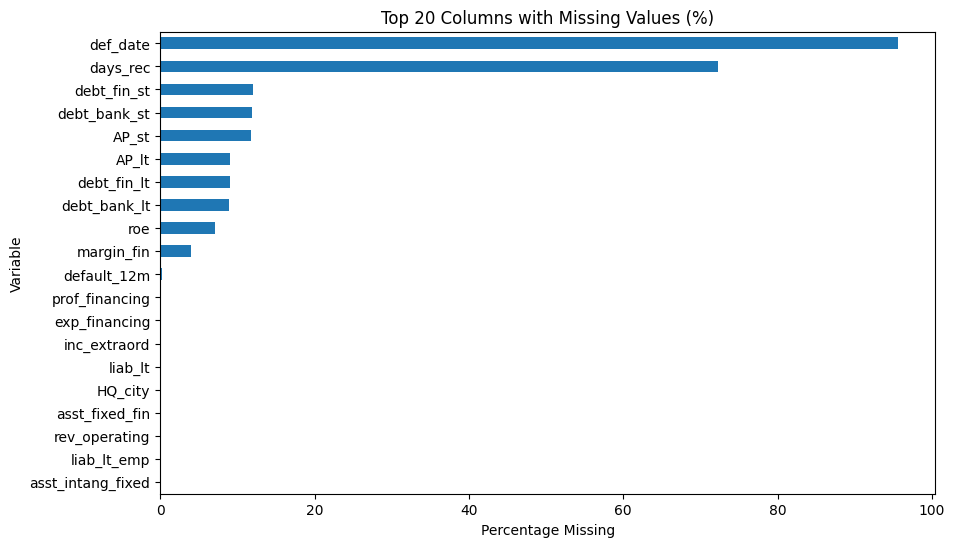

In [192]:
# 1️⃣ Calculate missing values count and percentage
missing_summary = (
    df.isna()
    .sum()
    .to_frame("missing_count")
    .assign(total_rows=len(df))
)
missing_summary["missing_pct"] = (
    100 * missing_summary["missing_count"] / missing_summary["total_rows"]
)

# 2️⃣ Sort by percentage descending
missing_summary = missing_summary.sort_values("missing_pct", ascending=False)

# 3️⃣ Display top 20 variables with most missing values
print("\n Variables with missing data:")
print(missing_summary)

# 4️⃣ (Optional) Visual summary if you want to visualize quickly
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
missing_summary["missing_pct"].head(20).plot(kind="barh")
plt.title("Top 20 Columns with Missing Values (%)")
plt.xlabel("Percentage Missing")
plt.ylabel("Variable")
plt.gca().invert_yaxis()
plt.show()

In [193]:
# Count missing values per column separately for defaulted vs non-defaulted companies
missing_by_flag = (
    df.groupby("default_12m")
      .agg(lambda x: x.isna().sum())
      .T
)

missing_by_flag_pct = (
    df.groupby(df["default_12m"])
      .agg(lambda x: x.isna().mean() * 100)
      .T
)
# Combine both counts and percentages
missing_summary = missing_by_flag.join(
    missing_by_flag_pct,
    lsuffix="_count",
    rsuffix="_pct"
)

# Sort by missing percentage for defaulters
missing_summary = missing_summary.sort_values("1_pct", ascending=False)

print("🔍 Missing values per variable by default status (count and %):")
print(missing_summary)

🔍 Missing values per variable by default status (count and %):
default_12m        0_count  1_count      0_pct      1_pct
days_rec            730116     8226  72.305107  73.736106
roe                  66314     4949   6.567232  44.361778
margin_fin           35529     3800   3.518521  34.062388
debt_fin_st         120860     1588  11.969050  14.234493
debt_bank_st        119449     1564  11.829316  14.019362
AP_st               118760     1559  11.761082  13.974543
AP_lt                90947     1070   9.006696   9.591251
debt_fin_lt          90775     1065   8.989662   9.546432
debt_bank_lt         89699     1049   8.883103   9.403012
prof_financing         642       13   0.063579   0.116529
HQ_city                265       12   0.026244   0.107565
inc_extraord           297        8   0.029413   0.071710
exp_financing          359        7   0.035553   0.062747
liab_lt                288        6   0.028521   0.053783
rev_operating          170        4   0.016836   0.035855
debt_lt  

In [194]:
df=df.drop(columns=["days_rec"],inplace=False)
df=df.drop(columns=["def_date"],inplace=False)

## Correlation Check

In [195]:
import pandas as pd
import numpy as np

# Select only numeric columns (exclude IDs, categorical, etc.)
num_df = df.select_dtypes(include=[np.number]).copy()

# Optionally drop columns that are constant or have too few unique values
num_df = num_df.loc[:, num_df.nunique() > 1]

# Compute Pearson correlation matrix
corr_matrix = num_df.corr(method='pearson')

# Summarize strongest correlations
# We'll unstack the matrix and sort by absolute correlation
corr_summary = (
    corr_matrix.unstack()
    .reset_index()
    .rename(columns={'level_0': 'Variable_1', 'level_1': 'Variable_2', 0: 'Correlation'})
)

# Remove self-correlations and duplicate pairs
corr_summary = corr_summary[corr_summary['Variable_1'] < corr_summary['Variable_2']]

# Add absolute correlation for sorting
corr_summary['Abs_Corr'] = corr_summary['Correlation'].abs()

# Sort by strongest correlations
corr_summary = corr_summary.sort_values('Abs_Corr', ascending=False)

# Display top 20 strongest relationships
print("\n Strongest correlations between numeric variables:\n")
display(corr_summary)


 Strongest correlations between numeric variables:



,Variable_1,Variable_2,Correlation,Abs_Corr
983,COGS,rev_operating,0.996275,0.996275
1311,profit,taxes,0.968024,0.968024
252,asst_tang_fixed,eqty_tot,0.933470,0.933470
341,asst_current,debt_st,0.933309,0.933309
251,asst_tang_fixed,asst_tot,0.932832,0.932832
...,...,...,...,...
93,HQ_city,liab_lt,-0.000086,0.000086
839,AP_lt,default_12m,0.000073,0.000073
364,AR,fs_year,-0.000051,0.000051
117,HQ_city,margin_fin,0.000029,0.000029


In [196]:
corr_default = corr_summary[
    (corr_summary['Variable_1'] == 'default_12m') | 
    (corr_summary['Variable_2'] == 'default_12m') 
    # (corr_summary['Variable_1'] == 'profit') |
    # (corr_summary['Variable_2'] == 'taxes')  
    ].sort_values('Abs_Corr', ascending=False)

print("\nStrongest correlations involving default_12m:\n")
display(corr_default)


Strongest correlations involving default_12m:



,Variable_1,Variable_2,Correlation,Abs_Corr
39,Unnamed: 0,default_12m,0.179555,0.179555
1594,default_12m,roa,-0.151527,0.151527
1595,default_12m,roe,-0.034024,0.034024
1564,default_12m,fs_year,-0.016409,0.016409
1592,default_12m,profit,-0.015555,0.015555
1591,default_12m,taxes,-0.013632,0.013632
639,debt_bank_st,default_12m,0.012029,0.012029
1559,cf_operations,default_12m,-0.011214,0.011214
159,ateco_sector,default_12m,-0.009913,0.009913
1585,default_12m,prof_operations,-0.009084,0.009084


## Primary Feature Engineering

### days_rec

Creating a days_rec column based of Accounts Receivable (represents money owed to a company by it's customers for goods or services delivered but not yet paid for ) and Revenue Operation :

$AR/Rev Operating * 365 = Days Recievables Approximation$

```python
df["days_rec_approx"] = np.where(
    df["rev_operating"].notna() & (df["rev_operating"] != 0) & df["AR"].notna(),
    (df["AR"] / df["rev_operating"]) * 365,
    np.nan
)

upper_cap = df["days_rec_approx"].abs().quantile(0.995)
df["days_rec_approx"] = df["days_rec_approx"].clip(-upper_cap, upper_cap)
df     
````

### Return on Equity Calculation

In [197]:
# Ensure numeric
df["profit"]   = pd.to_numeric(df["profit"], errors="coerce")
df["eqty_tot"] = pd.to_numeric(df["eqty_tot"], errors="coerce")

# ε applied ONLY where equity == 0
eps = 1e-6 * df["eqty_tot"].abs().max()  # scale-aware epsilon
adj_equity = df["eqty_tot"].mask(df["eqty_tot"].eq(0), eps)

# Base ROE (%) with special-case for profit == 0
roe_raw = (df["profit"] / adj_equity) * 100
roe_raw = roe_raw.mask(df["profit"].eq(0) & df["eqty_tot"].notna(), 0.0)

# Optional: squash numerical lint like -7.2e-8 to 0
tiny = 1e-6
roe_clean = roe_raw.where(roe_raw.abs() >= tiny, 0.0)

# Optional: mild winsorization (adjust or skip if you prefer)
lo, hi = roe_clean.quantile([0.01, 0.99])
roe_final = roe_clean.clip(lower=lo, upper=hi)

# Save rounded result
df["roe_calc"] = roe_final.round(2)

# Quick sanity summary
summary = {
    "epsilon": float(eps),
    "n_eps_applied(eqty==0)": int(df["eqty_tot"].eq(0).sum()),
    "winsor_limits": (float(lo), float(hi)),
}
summary

{'epsilon': 33564.879,
 'n_eps_applied(eqty==0)': 15,
 'winsor_limits': (-544.0358896582952, 249.10510818445832)}

In [198]:
# Compare only where both are non-missing
mask = df["roe"].notna() & df["roe_calc"].notna()

# Boolean: same up to 2 decimals
same = np.isclose(df.loc[mask, "roe"], df.loc[mask, "roe_calc"], atol=0.01)

df["missing_roe"]=df["roe"].isna().astype(int)

# Counts
n_same = same.sum()
n_diff = (~same).sum()
n_total = mask.sum()

print(f"Compared rows: {n_total:,}")
print(f"Same (±0.01):  {n_same:,} ({n_same/n_total:.2%})")
print(f"Different:     {n_diff:,} ({n_diff/n_total:.2%})")

Compared rows: 950,615
Same (±0.01):  950,523 (99.99%)
Different:     92 (0.01%)


In [199]:
variable_pd_analysis(df,["roe_calc","missing_roe"],combined=True)



================  roe_calc  ================

=== Logistic Regression for roe_calc (pooled, no year FE) ===

                           Logit Regression Results                           
Dep. Variable:            default_12m   No. Observations:              1020927
Model:                          Logit   Df Residuals:                  1020925
Method:                           MLE   Df Model:                            1
Date:                Wed, 12 Nov 2025   Pseudo R-squ.:               0.0001175
Time:                        23:44:12   Log-Likelihood:                -61474.
converged:                       True   LL-Null:                       -61481.
Covariance Type:                  HC1   LLR p-value:                 0.0001441
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -4.5053      0.010   -473.062      0.000      -4.524      -4.487
roe_calc       0.000

{'univariate': {'roe_calc': <statsmodels.discrete.discrete_model.BinaryResultsWrapper at 0x12069aa70>,
  'missing_roe': <statsmodels.discrete.discrete_model.BinaryResultsWrapper at 0x120698fd0>},
 'univariate_yearfe': {},
 'yearly': {'roe_calc': [(2007, -0.0003160759781029547, 0.6431298534197514),
   (2008, 0.00123437388517147, 0.12447211780637239),
   (2009, 0.0002833542938649829, 0.6010031944027328),
   (2010, -0.0002452303078224142, 0.5818880205591495),
   (2011, 0.00046398374652634476, 0.426567575335808),
   (2012, 0.011402067496567877, 4.991952535086476e-14)],
  'missing_roe': [(2007, 2.27778730430084, 2.00297940944315e-310),
   (2008, 2.5381401788699387, 0.0),
   (2009, 2.5253564986972084, 0.0),
   (2010, 2.348972805081812, 0.0),
   (2011, 2.46613023505586, 0.0),
   (2012, 3.604249341251371, 8.034743481496555e-108)]},
 'combined': <statsmodels.discrete.discrete_model.BinaryResultsWrapper at 0x1200841c0>,
 'combined_margeff': <statsmodels.discrete.discrete_margins.DiscreteMargins 

In [200]:
# Standardize only non-missing values
df["roe_z"] = scaler.fit_transform(df[["roe_calc"]])

# Recreate squared term based on standardized ROE
df["roe_z_sq"] = df["roe_z"] ** 2

variable_pd_analysis(df,["roe_z","missing_roe"],combined=True)




================  roe_z  ================

=== Logistic Regression for roe_z (pooled, no year FE) ===

                           Logit Regression Results                           
Dep. Variable:            default_12m   No. Observations:              1020927
Model:                          Logit   Df Residuals:                  1020925
Method:                           MLE   Df Model:                            1
Date:                Wed, 12 Nov 2025   Pseudo R-squ.:               0.0001175
Time:                        23:44:15   Log-Likelihood:                -61474.
converged:                       True   LL-Null:                       -61481.
Covariance Type:                  HC1   LLR p-value:                 0.0001441
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -4.5061      0.010   -471.825      0.000      -4.525      -4.487
roe_z          0.0380     

{'univariate': {'roe_z': <statsmodels.discrete.discrete_model.BinaryResultsWrapper at 0x12069a650>,
  'missing_roe': <statsmodels.discrete.discrete_model.BinaryResultsWrapper at 0x120086d10>},
 'univariate_yearfe': {},
 'yearly': {'roe_z': [(2007, -0.02614671690001794, 0.6431298534197747),
   (2008, 0.10211096938800168, 0.12447211780633922),
   (2009, 0.02343988476618407, 0.6010031944027383),
   (2010, -0.020286158639516483, 0.5818880205591286),
   (2011, 0.03838207427039074, 0.42656757533585354),
   (2012, 0.9432119223263083, 4.9919525350871965e-14)],
  'missing_roe': [(2007, 2.27778730430084, 2.00297940944315e-310),
   (2008, 2.5381401788699387, 0.0),
   (2009, 2.5253564986972084, 0.0),
   (2010, 2.348972805081812, 0.0),
   (2011, 2.46613023505586, 0.0),
   (2012, 3.604249341251371, 8.034743481496555e-108)]},
 'combined': <statsmodels.discrete.discrete_model.BinaryResultsWrapper at 0x12069bac0>,
 'combined_margeff': <statsmodels.discrete.discrete_margins.DiscreteMargins at 0x120698df

/var/folders/x_/s8b8dhh96pvg3fj1cx8cy61h0000gn/T/ipykernel_3258/2170920069.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('dec')['default_12m'].mean().plot(kind='bar')


<Axes: xlabel='dec'>

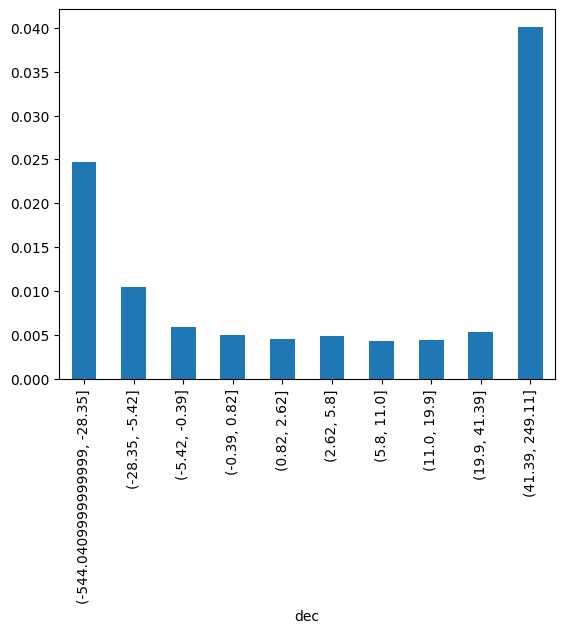

In [201]:
df['dec'] = pd.qcut(df['roe_calc'], 10, duplicates='drop')
df.groupby('dec')['default_12m'].mean().plot(kind='bar')

### Gross Profit Margin

gross_profit_margin    1.000000
rev_operating          0.007535
COGS                   0.005543
default_12m           -0.037472
dtype: float64


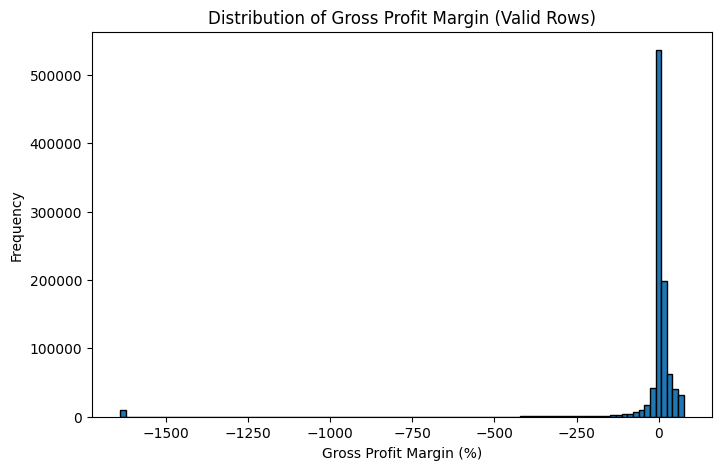

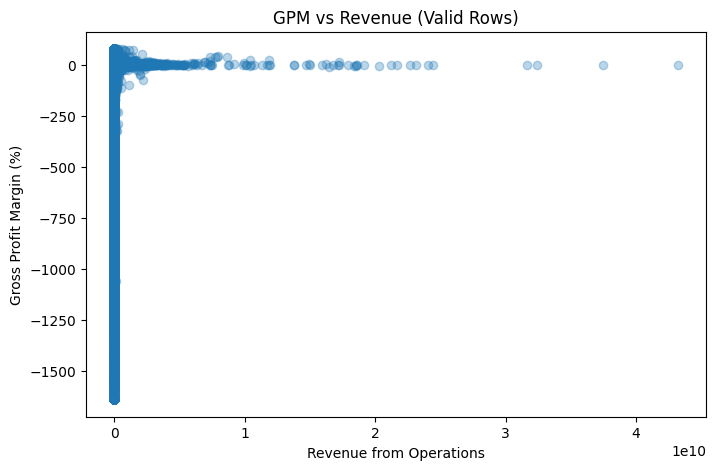

In [202]:
# Ensure numeric
df["rev_operating"] = pd.to_numeric(df["rev_operating"], errors="coerce")
df["COGS"] = pd.to_numeric(df["COGS"], errors="coerce")

rev, cogs = df["rev_operating"], df["COGS"]

# Case flags
df["rev_cogs_case"] = np.select(
    [
        (rev > 0) & (cogs >= 0),
        (rev < 0) & (cogs < 0),
        (rev < 0) & (cogs > 0),
        (rev > 0) & (cogs < 0),
        (rev == 0) | (cogs.isna())
    ],
    [
        "valid",
        "reversal_both_neg",
        "invalid_rev_neg_cogs_pos",
        "invalid_rev_pos_cogs_neg",
        "zero_or_missing"
    ],
    default="other"
)

df["invalid_rev_cogs_flag"] = df["rev_cogs_case"].isin(
    ["reversal_both_neg", "invalid_rev_neg_cogs_pos", "invalid_rev_pos_cogs_neg", "zero_or_missing"]
).astype(int)

mask_valid = df["invalid_rev_cogs_flag"] == 0

# GPM only on valid rows
df["gross_profit_margin"] = np.nan
df.loc[mask_valid, "gross_profit_margin"] = (
    (df.loc[mask_valid, "rev_operating"] - df.loc[mask_valid, "COGS"])
    / df.loc[mask_valid, "rev_operating"] * 100
)

# Tiny numerical lint → 0
tiny = 1e-6
v = df.loc[mask_valid, "gross_profit_margin"]
df.loc[mask_valid, "gross_profit_margin"] = v.where(v.abs() >= tiny, 0.0)

# Winsorize using valid, non-null GPMs only
q_low, q_high = df.loc[mask_valid, "gross_profit_margin"].dropna().quantile([0.01, 0.99])
v = df.loc[mask_valid, "gross_profit_margin"]
df.loc[mask_valid, "gross_profit_margin"] = v.clip(q_low, q_high).round(2)

# Keep this flag as a feature, and drop rev/COGS if you’re using GPM
df["gross_profit_margin_filled"] = df["gross_profit_margin"].fillna(0.0)

# --- EDA ---
df_valid = df.loc[mask_valid, ["gross_profit_margin", "rev_operating", "COGS", "default_12m"]]

print(df_valid.corrwith(df_valid["gross_profit_margin"]))

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(df_valid["gross_profit_margin"].dropna(), bins=100, edgecolor="k")
plt.xlabel("Gross Profit Margin (%)")
plt.ylabel("Frequency")
plt.title("Distribution of Gross Profit Margin (Valid Rows)")
plt.show()

plt.figure(figsize=(8, 5))
plt.scatter(df_valid["rev_operating"], df_valid["gross_profit_margin"], alpha=0.3)
plt.xlabel("Revenue from Operations")
plt.ylabel("Gross Profit Margin (%)")
plt.title("GPM vs Revenue (Valid Rows)")
plt.show()

In [203]:
# Standardize only non-missing values
df["gross_profit_margin_filled_z"] = scaler.fit_transform(df[["gross_profit_margin_filled"]])

In [204]:
variable_pd_analysis(df, ["gross_profit_margin_filled_z","invalid_rev_cogs_flag"],combined=True)



================  gross_profit_margin_filled_z  ================

=== Logistic Regression for gross_profit_margin_filled_z (pooled, no year FE) ===

                           Logit Regression Results                           
Dep. Variable:            default_12m   No. Observations:              1020927
Model:                          Logit   Df Residuals:                  1020925
Method:                           MLE   Df Model:                            1
Date:                Wed, 12 Nov 2025   Pseudo R-squ.:                0.006303
Time:                        23:44:21   Log-Likelihood:                -61093.
converged:                       True   LL-Null:                       -61481.
Covariance Type:                  HC1   LLR p-value:                1.429e-170
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const                  

{'univariate': {'gross_profit_margin_filled_z': <statsmodels.discrete.discrete_model.BinaryResultsWrapper at 0x127ca7ca0>,
  'invalid_rev_cogs_flag': <statsmodels.discrete.discrete_model.BinaryResultsWrapper at 0x1200dce20>},
 'univariate_yearfe': {},
 'yearly': {'gross_profit_margin_filled_z': [(2007,
    -0.15560406809345664,
    1.0236202356316662e-27),
   (2008, -0.18040821735882154, 1.3515276656028073e-72),
   (2009, -0.18333223929542394, 2.0634234654543573e-108),
   (2010, -0.1581825080903973, 3.947960717657484e-79),
   (2011, -0.1650137319643441, 2.876680121745761e-80),
   (2012, -0.22957815866162462, 1.0653223277642051e-22)],
  'invalid_rev_cogs_flag': [(2007, 0.14623659951908932, 0.32326550789704955),
   (2008, 0.18923605282751313, 0.09610722414698418),
   (2009, 0.476886239171473, 1.5510689734346572e-08),
   (2010, 0.6558298975250718, 4.227383670424669e-19),
   (2011, 0.8027211121699347, 1.2744642998525534e-25),
   (2012, 1.3537505304964776, 1.2772877077161218e-10)]},
 'combi

In [205]:
df["gpm_flag_interaction"] = df["gross_profit_margin_filled_z"] * df["invalid_rev_cogs_flag"]
variable_pd_analysis(df,"gpm_flag_interaction")



================  gpm_flag_interaction  ================

=== Logistic Regression for gpm_flag_interaction (pooled, no year FE) ===

                           Logit Regression Results                           
Dep. Variable:            default_12m   No. Observations:              1020927
Model:                          Logit   Df Residuals:                  1020925
Method:                           MLE   Df Model:                            1
Date:                Wed, 12 Nov 2025   Pseudo R-squ.:                0.001439
Time:                        23:44:24   Log-Likelihood:                -61392.
converged:                       True   LL-Null:                       -61481.
Covariance Type:                  HC1   LLR p-value:                 2.209e-40
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   -4.5331      0.010   -460.973  

{'univariate': {'gpm_flag_interaction': <statsmodels.discrete.discrete_model.BinaryResultsWrapper at 0x11fe0c190>},
 'univariate_yearfe': {},
 'yearly': {'gpm_flag_interaction': [(2007,
    1.4796197460269467,
    0.32326550789702413),
   (2008, 1.9146875771496588, 0.09610722414702391),
   (2009, 4.825127898262923, 1.5510689734290062e-08),
   (2010, 6.635677180706683, 4.227383670484993e-19),
   (2011, 8.121920312871719, 1.27446429988625e-25),
   (2012, 13.697227798678583, 1.2772877077141994e-10)]},
 'combined': None,
 'combined_margeff': None,
 'corr_combined': None}

In [206]:
df_cogs=df.dropna(subset=["COGS"],inplace=False).copy()
df_cogs["COGS_z"] = scaler.fit_transform(df_cogs[["COGS"]])
variable_pd_analysis(df_cogs,"COGS_z")



================  COGS_z  ================

=== Logistic Regression for COGS_z (pooled, no year FE) ===

                           Logit Regression Results                           
Dep. Variable:            default_12m   No. Observations:              1020903
Model:                          Logit   Df Residuals:                  1020901
Method:                           MLE   Df Model:                            1
Date:                Wed, 12 Nov 2025   Pseudo R-squ.:               0.0002862
Time:                        23:44:26   Log-Likelihood:                -61463.
converged:                       True   LL-Null:                       -61481.
Covariance Type:                  HC1   LLR p-value:                 2.981e-09
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -4.5107      0.010   -468.041      0.000      -4.530      -4.492
COGS_z        -0.3185   

{'univariate': {'COGS_z': <statsmodels.discrete.discrete_model.BinaryResultsWrapper at 0x127ca49d0>},
 'univariate_yearfe': {},
 'yearly': {'COGS_z': [(2007, -0.18423980593444403, 0.3947548021525189),
   (2008, -0.1388857972881946, 0.05336899866238243),
   (2009, -0.19366161787553446, 0.029356080209713642),
   (2010, -0.576130453315891, 0.009704475295977066),
   (2011, -0.5168188601985828, 0.008086179344455336),
   (2012, -0.262574966646353, 0.20172344229031847)]},
 'combined': None,
 'combined_margeff': None,
 'corr_combined': None}

In [207]:
variable_pd_analysis(df_cogs, ["gross_profit_margin_filled_z","invalid_rev_cogs_flag","COGS_z"],combined=True)



================  gross_profit_margin_filled_z  ================

=== Logistic Regression for gross_profit_margin_filled_z (pooled, no year FE) ===

                           Logit Regression Results                           
Dep. Variable:            default_12m   No. Observations:              1020903
Model:                          Logit   Df Residuals:                  1020901
Method:                           MLE   Df Model:                            1
Date:                Wed, 12 Nov 2025   Pseudo R-squ.:                0.006303
Time:                        23:44:28   Log-Likelihood:                -61093.
converged:                       True   LL-Null:                       -61481.
Covariance Type:                  HC1   LLR p-value:                1.444e-170
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const                  

{'univariate': {'gross_profit_margin_filled_z': <statsmodels.discrete.discrete_model.BinaryResultsWrapper at 0x1200ddf60>,
  'invalid_rev_cogs_flag': <statsmodels.discrete.discrete_model.BinaryResultsWrapper at 0x11f0e5630>,
  'COGS_z': <statsmodels.discrete.discrete_model.BinaryResultsWrapper at 0x11f0e4430>},
 'univariate_yearfe': {},
 'yearly': {'gross_profit_margin_filled_z': [(2007,
    -0.1555966351699982,
    1.0288328808737394e-27),
   (2008, -0.18040339719056736, 1.362439284391031e-72),
   (2009, -0.1833301969007312, 2.074451709854091e-108),
   (2010, -0.15818118407439274, 3.959371927186729e-79),
   (2011, -0.16501249431344484, 2.8841166382117296e-80),
   (2012, -0.22957815866162462, 1.0653223277642051e-22)],
  'invalid_rev_cogs_flag': [(2007, 0.14822546254540162, 0.31673277547786427),
   (2008, 0.1904345804943129, 0.09402218708732693),
   (2009, 0.4773649753172123, 1.500869259272828e-08),
   (2010, 0.6561238422655774, 4.0784325615386404e-19),
   (2011, 0.8030314784045699, 1.2

In [208]:
# X = sm.add_constant(df[["gross_profit_margin_filled_z", "invalid_rev_cogs_flag","gpm_flag_interaction"]])
# model = sm.Logit(df["default_12m"], X).fit()
# print(model.summary())

# # Marginal effects
# marg_eff = model.get_margeff(at='mean', method='dydx')
# print("\nMarginal Effects at the Means:\n")
# print(marg_eff.summary())

### Margin_fin (Equity-Assests)

In [209]:
# 1️⃣ Recalculate margin_fin from components
df["margin_calc"] = (
    df["eqty_tot"]
    - df[["asst_intang_fixed", "asst_tang_fixed", "asst_fixed_fin"]].sum(axis=1)
)

# 2️⃣ Create missing flag
df["missing_margin_flag"] = df["margin_fin"].isna().astype(int)

# 3️⃣ Create a filled version (use reported if available, else calculated)
df["margin_fin_filled"] = np.where(
    df["margin_fin"].notna(), df["margin_fin"], df["margin_calc"]
)

# 4️⃣ Quick check
print("\n=== margin_fin Missingness Summary ===")
n_total = len(df)
n_missing = df["missing_margin_flag"].sum()
print(f"Total rows:       {n_total:,}")
print(f"Missing margin:   {n_missing:,} ({n_missing/n_total*100:.2f}%)")
print(f"Filled values:    {n_total - n_missing:,} ({(n_total - n_missing)/n_total*100:.2f}%)")

# 5️⃣ Sanity check of valid rows comparison (optional)
mask = df["margin_fin"].notna() & df["margin_calc"].notna()
same = (np.abs(df.loc[mask, "margin_calc"] - df.loc[mask, "margin_fin"]) < 0.01).sum()
print(f"\nOf {mask.sum():,} valid rows, {same:,} ({same/mask.sum()*100:.2f}%) match within ±0.01")

# (Optional) look at flag effect
print("\nFlag correlation with default rate:")
print(df.groupby("missing_margin_flag")["default_12m"].mean())


=== margin_fin Missingness Summary ===
Total rows:       1,023,552
Missing margin:   40,758 (3.98%)
Filled values:    982,794 (96.02%)

Of 982,794 valid rows, 981,130 (99.83%) match within ±0.01

Flag correlation with default rate:
missing_margin_flag
0    0.007494
1    0.096621
Name: default_12m, dtype: Float64


In [210]:
df["margin_fin_filled"].isna().sum()

np.int64(1)

In [211]:
df.dropna(subset=["margin_fin_filled"], inplace=True)

In [212]:
variable_pd_analysis(df, ['margin_fin_filled',"missing_margin_flag"],combined=True)




================  margin_fin_filled  ================

=== Logistic Regression for margin_fin_filled (pooled, no year FE) ===

                           Logit Regression Results                           
Dep. Variable:            default_12m   No. Observations:              1020926
Model:                          Logit   Df Residuals:                  1020924
Method:                           MLE   Df Model:                            1
Date:                Wed, 12 Nov 2025   Pseudo R-squ.:               4.669e-06
Time:                        23:44:33   Log-Likelihood:                -61480.
converged:                       True   LL-Null:                       -61481.
Covariance Type:                  HC1   LLR p-value:                    0.4487
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                -4.5056      0.010   -473.283      0.000      

{'univariate': {'margin_fin_filled': <statsmodels.discrete.discrete_model.BinaryResultsWrapper at 0x11fe0c940>,
  'missing_margin_flag': <statsmodels.discrete.discrete_model.BinaryResultsWrapper at 0x127ca5f00>},
 'univariate_yearfe': {},
 'yearly': {'margin_fin_filled': [(2007,
    -1.4258708129344337e-11,
    0.695781770064021),
   (2008, -5.950328378120782e-11, 0.08092064610046866),
   (2009, -4.783413374591756e-11, 0.13657558128264063),
   (2010, -1.0630384382139147e-10, 0.23141835706072833),
   (2011, -2.8614855980479125e-10, 0.001185592456956948),
   (2012, -2.8211183971860406e-10, 3.431640533344827e-05)],
  'missing_margin_flag': [(2007, 2.4531741015463755, 3.9389149877079e-310),
   (2008, 2.7592739647609026, 0.0),
   (2009, 2.7320095477221535, 0.0),
   (2010, 2.5733194991417436, 0.0),
   (2011, 2.72289571871971, 0.0),
   (2012, 3.8736663928179444, 8.570854204058293e-146)]},
 'combined': <statsmodels.discrete.discrete_model.BinaryResultsWrapper at 0x11f299c60>,
 'combined_margef

### Financial Leverage = roe / roa

Dropping the rows cause it is only from the non defaults so need to impute the missing values

In [213]:
df=df.dropna(subset=["roa"], inplace=False).copy()
variable_pd_analysis(df,"roa")



================  roa  ================

=== Logistic Regression for roa (pooled, no year FE) ===

                           Logit Regression Results                           
Dep. Variable:            default_12m   No. Observations:              1020900
Model:                          Logit   Df Residuals:                  1020898
Method:                           MLE   Df Model:                            1
Date:                Wed, 12 Nov 2025   Pseudo R-squ.:                 0.06594
Time:                        23:44:36   Log-Likelihood:                -57422.
converged:                       True   LL-Null:                       -61476.
Covariance Type:                  HC1   LLR p-value:                     0.000
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -4.5109      0.010   -461.093      0.000      -4.530      -4.492
roa           -0.0467      0.0

{'univariate': {'roa': <statsmodels.discrete.discrete_model.BinaryResultsWrapper at 0x11f0ee7d0>},
 'univariate_yearfe': {},
 'yearly': {'roa': [(2007, -0.048129866689919525, 6.911131594343723e-57),
   (2008, -0.04708152513186298, 4.842511301895253e-44),
   (2009, -0.060358328081277064, 1.6448590064144743e-134),
   (2010, -0.0545510142881664, 3.449572037204245e-62),
   (2011, -0.052879273534215766, 1.5988672508166274e-84),
   (2012, -0.026495422711839023, 2.9157903617309283e-12)]},
 'combined': None,
 'combined_margeff': None,
 'corr_combined': None}

In [214]:
# Compute Financial Leverage
df["Financial_Leverage"] = np.where(
    (df["roa"] == 0) & (df["roe_calc"] == 0),
    0,
    df["roe_calc"] / df["roa"]
    )
# Winsorize to 1st–99th percentile range
lo, hi = df["Financial_Leverage"].quantile([0.01, 0.99])
df["Financial_Leverage"] = df["Financial_Leverage"].clip(lower=lo, upper=hi)

# Optionally round or report
summary = {
    "winsor_limits": (float(lo), float(hi)),
    "num_missing": int(df["Financial_Leverage"].isna().sum())
}

In [215]:
print(summary)

{'winsor_limits': (-350.8634944803959, 394.1707890961268), 'num_missing': 0}


In [216]:
df

,Unnamed: 0,id,stmt_date,HQ_city,legal_struct,ateco_sector,fs_year,asst_intang_fixed,asst_tang_fixed,asst_fixed_fin,...,rev_cogs_case,invalid_rev_cogs_flag,gross_profit_margin,gross_profit_margin_filled,gross_profit_margin_filled_z,gpm_flag_interaction,margin_calc,missing_margin_flag,margin_fin_filled,Financial_Leverage
0,17,520288,2011-12-31,28.0,SRL,14.0,2011,67537.0,1137566.0,1908.0,...,valid,0,-13.78,-13.78,0.022114,0.000000,-917029.0,0,-917029.0,7.356955
1,18,520288,2008-12-31,28.0,SRL,14.0,2008,256438.0,1181416.0,860.0,...,valid,0,-5.93,-5.93,0.065819,0.000000,-1476039.0,1,-1476039.0,-90.257246
2,19,520288,2009-12-31,28.0,SRL,14.0,2009,194046.0,1152014.0,860.0,...,valid,0,-6.71,-6.71,0.061476,0.000000,-1392059.0,1,-1392059.0,-79.447005
3,21,520288,2012-12-31,28.0,SRL,14.0,2012,15195.0,1116938.0,2023.0,...,valid,0,-76.10,-76.10,-0.324853,-0.000000,-1094962.0,0,-1094962.0,41.881447
4,22,520288,2007-12-31,28.0,SRL,14.0,2007,126603.0,1127807.0,620.0,...,valid,0,5.38,5.38,0.128787,0.000000,-1184970.0,0,-1184970.0,8.456452
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1023547,4885791,92001230520,2011-12-31,52.0,SPA,93.0,2011,1498628.0,248233.0,163477.0,...,valid,0,0.81,0.81,0.103344,0.000000,-1286111.0,0,-1286111.0,-19.907407
1023548,4885792,92001230520,2008-12-31,52.0,SPA,93.0,2008,2465065.0,343015.0,43477.0,...,valid,0,4.63,4.63,0.124611,0.000000,-2212557.0,0,-2212557.0,0.077872
1023549,4885793,92001230520,2007-12-31,52.0,SPA,93.0,2007,2375606.0,261775.0,28642.0,...,valid,0,2.72,2.72,0.113978,0.000000,-2033490.0,0,-2033489.0,0.100813
1023550,4885815,94111750108,2010-12-31,10.0,SRL,68.0,2010,2973.0,1131586.0,264600.0,...,zero_or_missing,1,NaN,0.00,0.098834,0.098834,-1140392.0,0,-1140392.0,5.967742


In [217]:
df["Financial_Leverage_z"] = scaler.fit_transform(df[["Financial_Leverage"]])
variable_pd_analysis(df,"Financial_Leverage_z") 



================  Financial_Leverage_z  ================

=== Logistic Regression for Financial_Leverage_z (pooled, no year FE) ===

                           Logit Regression Results                           
Dep. Variable:            default_12m   No. Observations:              1020900
Model:                          Logit   Df Residuals:                  1020898
Method:                           MLE   Df Model:                            1
Date:                Wed, 12 Nov 2025   Pseudo R-squ.:               2.820e-06
Time:                        23:44:38   Log-Likelihood:                -61476.
converged:                       True   LL-Null:                       -61476.
Covariance Type:                  HC1   LLR p-value:                    0.5560
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   -4.5056      0.010   -473.247  

{'univariate': {'Financial_Leverage_z': <statsmodels.discrete.discrete_model.BinaryResultsWrapper at 0x11f07a470>},
 'univariate_yearfe': {},
 'yearly': {'Financial_Leverage_z': [(2007,
    -0.03489146650697675,
    0.3526801026937484),
   (2008, -0.01603144105269464, 0.5971472971863947),
   (2009, -0.001125951162750577, 0.9629453528900065),
   (2010, 0.019699727181873204, 0.4254395978059923),
   (2011, 0.035736666971144436, 0.17232746924200215),
   (2012, -0.11210057176115537, 0.1995251039543945)]},
 'combined': None,
 'combined_margeff': None,
 'corr_combined': None}

In [218]:
# Standardize only non-missing values
df["roa_z"] = scaler.fit_transform(df[["roa"]])
variable_pd_analysis(df,"roa_z") 



================  roa_z  ================

=== Logistic Regression for roa_z (pooled, no year FE) ===

                           Logit Regression Results                           
Dep. Variable:            default_12m   No. Observations:              1020900
Model:                          Logit   Df Residuals:                  1020898
Method:                           MLE   Df Model:                            1
Date:                Wed, 12 Nov 2025   Pseudo R-squ.:                 0.06594
Time:                        23:44:39   Log-Likelihood:                -57422.
converged:                       True   LL-Null:                       -61476.
Covariance Type:                  HC1   LLR p-value:                     0.000
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -4.6471      0.011   -435.092      0.000      -4.668      -4.626
roa_z         -0.4783     

{'univariate': {'roa_z': <statsmodels.discrete.discrete_model.BinaryResultsWrapper at 0x11f0b29e0>},
 'univariate_yearfe': {},
 'yearly': {'roa_z': [(2007, -0.49255116587480574, 6.911131594354275e-57),
   (2008, -0.48182265378516176, 4.842511301929281e-44),
   (2009, -0.6176947270230789, 1.6448590064126013e-134),
   (2010, -0.558263870963871, 3.449572037319465e-62),
   (2011, -0.5411556196008709, 1.5988672508316177e-84),
   (2012, -0.27114871169579674, 2.915790361736716e-12)]},
 'combined': None,
 'combined_margeff': None,
 'corr_combined': None}

In [219]:
variable_pd_analysis(df,["roa_z","Financial_Leverage_z"],combined=True)



================  roa_z  ================

=== Logistic Regression for roa_z (pooled, no year FE) ===

                           Logit Regression Results                           
Dep. Variable:            default_12m   No. Observations:              1020900
Model:                          Logit   Df Residuals:                  1020898
Method:                           MLE   Df Model:                            1
Date:                Wed, 12 Nov 2025   Pseudo R-squ.:                 0.06594
Time:                        23:44:41   Log-Likelihood:                -57422.
converged:                       True   LL-Null:                       -61476.
Covariance Type:                  HC1   LLR p-value:                     0.000
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -4.6471      0.011   -435.092      0.000      -4.668      -4.626
roa_z         -0.4783     

{'univariate': {'roa_z': <statsmodels.discrete.discrete_model.BinaryResultsWrapper at 0x11f0b25f0>,
  'Financial_Leverage_z': <statsmodels.discrete.discrete_model.BinaryResultsWrapper at 0x120690dc0>},
 'univariate_yearfe': {},
 'yearly': {'roa_z': [(2007, -0.49255116587480574, 6.911131594354275e-57),
   (2008, -0.48182265378516176, 4.842511301929281e-44),
   (2009, -0.6176947270230789, 1.6448590064126013e-134),
   (2010, -0.558263870963871, 3.449572037319465e-62),
   (2011, -0.5411556196008709, 1.5988672508316177e-84),
   (2012, -0.27114871169579674, 2.915790361736716e-12)],
  'Financial_Leverage_z': [(2007, -0.03489146650697675, 0.3526801026937484),
   (2008, -0.01603144105269464, 0.5971472971863947),
   (2009, -0.001125951162750577, 0.9629453528900065),
   (2010, 0.019699727181873204, 0.4254395978059923),
   (2011, 0.035736666971144436, 0.17232746924200215),
   (2012, -0.11210057176115537, 0.1995251039543945)]},
 'combined': <statsmodels.discrete.discrete_model.BinaryResultsWrapper 

In [220]:
variable_pd_analysis(df,["roa_z","roe_z"],combined=True,combined_only=True)



================  COMBINED MULTIVARIATE MODEL  ================

=== Logistic Regression (all variables, no year FE) ===

                           Logit Regression Results                           
Dep. Variable:            default_12m   No. Observations:              1020900
Model:                          Logit   Df Residuals:                  1020897
Method:                           MLE   Df Model:                            2
Date:                Wed, 12 Nov 2025   Pseudo R-squ.:                 0.06708
Time:                        23:44:44   Log-Likelihood:                -57352.
converged:                       True   LL-Null:                       -61476.
Covariance Type:                  HC1   LLR p-value:                     0.000
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -4.6471      0.011   -434.022      0.000      -4.668      -4.626
roa_z  

{'univariate': {},
 'univariate_yearfe': {},
 'yearly': {},
 'combined': <statsmodels.discrete.discrete_model.BinaryResultsWrapper at 0x120693bb0>,
 'combined_margeff': <statsmodels.discrete.discrete_margins.DiscreteMargins at 0x120690700>,
 'corr_combined':           roa_z     roe_z
 roa_z  1.000000  0.194377
 roe_z  0.194377  1.000000}

In [221]:
corr = df[["roe_z", "roa_z"]].corr(method="pearson")
print(corr)


          roe_z     roa_z
roe_z  1.000000  0.181708
roa_z  0.181708  1.000000


### Profit and Taxes

In [222]:
df=df.dropna(subset=["profit","taxes"],inplace=False).copy()

# Calculate effective tax rate safely
df["effective_tax_rate"] = np.where(
    (df["profit"] > 1e-4) & (df["taxes"] >= 0),
    df["taxes"] / (df["profit"]+df["taxes"]),
    np.nan  # avoid division by zero or meaningless negatives
)

# Winsorize to remove outliers
lo, hi = df["effective_tax_rate"].quantile([0.01, 0.99])
df["effective_tax_rate"] = df["effective_tax_rate"].clip(lower=lo, upper=hi)

# optional flags for modeling
df["missing_etr_flag"] = df["effective_tax_rate"].isna().astype(int)


# Fill missing with 0 for model stability
df["effective_tax_rate_filled"] = df["effective_tax_rate"].fillna(0)


summary = {
    "rows_after_dropna": int(len(df)),
    "valid_etr": int(df["effective_tax_rate"].notna().sum()),
    "winsor_limits": (None if pd.isna(lo) else float(lo),
                      None if pd.isna(hi) else float(hi)),
}
print(summary)

{'rows_after_dropna': 1023512, 'valid_etr': 656632, 'winsor_limits': (0.49039327974320895, 0.9835934404895004)}


In [223]:
df

,Unnamed: 0,id,stmt_date,HQ_city,legal_struct,ateco_sector,fs_year,asst_intang_fixed,asst_tang_fixed,asst_fixed_fin,...,gpm_flag_interaction,margin_calc,missing_margin_flag,margin_fin_filled,Financial_Leverage,Financial_Leverage_z,roa_z,effective_tax_rate,missing_etr_flag,effective_tax_rate_filled
0,17,520288,2011-12-31,28.0,SRL,14.0,2011,67537.0,1137566.0,1908.0,...,0.000000,-917029.0,0,-917029.0,7.356955,0.057619,-0.657097,NaN,1,0.000000
1,18,520288,2008-12-31,28.0,SRL,14.0,2008,256438.0,1181416.0,860.0,...,0.000000,-1476039.0,1,-1476039.0,-90.257246,-1.381422,-0.554496,NaN,1,0.000000
2,19,520288,2009-12-31,28.0,SRL,14.0,2009,194046.0,1152014.0,860.0,...,0.000000,-1392059.0,1,-1392059.0,-79.447005,-1.222056,-0.496844,NaN,1,0.000000
3,21,520288,2012-12-31,28.0,SRL,14.0,2012,15195.0,1116938.0,2023.0,...,-0.000000,-1094962.0,0,-1094962.0,41.881447,0.566583,-1.554125,NaN,1,0.000000
4,22,520288,2007-12-31,28.0,SRL,14.0,2007,126603.0,1127807.0,620.0,...,0.000000,-1184970.0,0,-1184970.0,8.456452,0.073828,0.321034,0.715082,0,0.715082
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1023547,4885791,92001230520,2011-12-31,52.0,SPA,93.0,2011,1498628.0,248233.0,163477.0,...,0.000000,-1286111.0,0,-1286111.0,-19.907407,-0.344316,-0.073736,NaN,1,0.000000
1023548,4885792,92001230520,2008-12-31,52.0,SPA,93.0,2008,2465065.0,343015.0,43477.0,...,0.000000,-2212557.0,0,-2212557.0,0.077872,-0.049690,0.982568,0.982197,0,0.982197
1023549,4885793,92001230520,2007-12-31,52.0,SPA,93.0,2007,2375606.0,261775.0,28642.0,...,0.000000,-2033490.0,0,-2033489.0,0.100813,-0.049352,0.316149,0.977466,0,0.977466
1023550,4885815,94111750108,2010-12-31,10.0,SRL,68.0,2010,2973.0,1131586.0,264600.0,...,0.098834,-1140392.0,0,-1140392.0,5.967742,0.037139,-0.315093,NaN,1,0.000000


In [224]:
df["effective_tax_rate_z"] = scaler.fit_transform(df[["effective_tax_rate_filled"]])

In [225]:
variable_pd_analysis(df, ["effective_tax_rate_z",'missing_etr_flag'],combined=True)



================  effective_tax_rate_z  ================

=== Logistic Regression for effective_tax_rate_z (pooled, no year FE) ===

                           Logit Regression Results                           
Dep. Variable:            default_12m   No. Observations:              1020887
Model:                          Logit   Df Residuals:                  1020885
Method:                           MLE   Df Model:                            1
Date:                Wed, 12 Nov 2025   Pseudo R-squ.:                 0.04630
Time:                        23:44:46   Log-Likelihood:                -58629.
converged:                       True   LL-Null:                       -61476.
Covariance Type:                  HC1   LLR p-value:                     0.000
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   -4.7750      0.012   -385.170  

{'univariate': {'effective_tax_rate_z': <statsmodels.discrete.discrete_model.BinaryResultsWrapper at 0x11fe0ce20>,
  'missing_etr_flag': <statsmodels.discrete.discrete_model.BinaryResultsWrapper at 0x11f0b39a0>},
 'univariate_yearfe': {},
 'yearly': {'effective_tax_rate_z': [(2007,
    -0.6396145114490532,
    3.3779028674457957e-94),
   (2008, -0.7651188664456411, 6.068221533640626e-166),
   (2009, -0.7488339569564451, 8.534647200259694e-216),
   (2010, -0.7342948739436824, 1.5582800589917848e-235),
   (2011, -0.7847213643689341, 6.342044057163948e-231),
   (2012, -1.3506640521819508, 1.7478930871773115e-25)],
  'missing_etr_flag': [(2007, 1.3782016836634992, 3.436511424028467e-115),
   (2008, 1.5992268815230168, 2.4398259772434942e-206),
   (2009, 1.5258044283041203, 1.3234215012281666e-250),
   (2010, 1.5229530460515035, 8.04925176548584e-290),
   (2011, 1.6333877078080672, 1.0549238612430731e-283),
   (2012, 2.684240169188663, 4.740469247627418e-30)]},
 'combined': <statsmodels.dis

In [226]:
df

,Unnamed: 0,id,stmt_date,HQ_city,legal_struct,ateco_sector,fs_year,asst_intang_fixed,asst_tang_fixed,asst_fixed_fin,...,margin_calc,missing_margin_flag,margin_fin_filled,Financial_Leverage,Financial_Leverage_z,roa_z,effective_tax_rate,missing_etr_flag,effective_tax_rate_filled,effective_tax_rate_z
0,17,520288,2011-12-31,28.0,SRL,14.0,2011,67537.0,1137566.0,1908.0,...,-917029.0,0,-917029.0,7.356955,0.057619,-0.657097,NaN,1,0.000000,-1.282433
1,18,520288,2008-12-31,28.0,SRL,14.0,2008,256438.0,1181416.0,860.0,...,-1476039.0,1,-1476039.0,-90.257246,-1.381422,-0.554496,NaN,1,0.000000,-1.282433
2,19,520288,2009-12-31,28.0,SRL,14.0,2009,194046.0,1152014.0,860.0,...,-1392059.0,1,-1392059.0,-79.447005,-1.222056,-0.496844,NaN,1,0.000000,-1.282433
3,21,520288,2012-12-31,28.0,SRL,14.0,2012,15195.0,1116938.0,2023.0,...,-1094962.0,0,-1094962.0,41.881447,0.566583,-1.554125,NaN,1,0.000000,-1.282433
4,22,520288,2007-12-31,28.0,SRL,14.0,2007,126603.0,1127807.0,620.0,...,-1184970.0,0,-1184970.0,8.456452,0.073828,0.321034,0.715082,0,0.715082,0.802276
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1023547,4885791,92001230520,2011-12-31,52.0,SPA,93.0,2011,1498628.0,248233.0,163477.0,...,-1286111.0,0,-1286111.0,-19.907407,-0.344316,-0.073736,NaN,1,0.000000,-1.282433
1023548,4885792,92001230520,2008-12-31,52.0,SPA,93.0,2008,2465065.0,343015.0,43477.0,...,-2212557.0,0,-2212557.0,0.077872,-0.049690,0.982568,0.982197,0,0.982197,1.581008
1023549,4885793,92001230520,2007-12-31,52.0,SPA,93.0,2007,2375606.0,261775.0,28642.0,...,-2033490.0,0,-2033489.0,0.100813,-0.049352,0.316149,0.977466,0,0.977466,1.567215
1023550,4885815,94111750108,2010-12-31,10.0,SRL,68.0,2010,2973.0,1131586.0,264600.0,...,-1140392.0,0,-1140392.0,5.967742,0.037139,-0.315093,NaN,1,0.000000,-1.282433


## Create ratios using debt and assests

In [227]:
# ---- total debt ----
df['debt_total'] = (
    df['liab_lt'].fillna(0)
    + df['debt_bank_st'].fillna(0)
    + df['debt_bank_lt'].fillna(0)
    + df['debt_fin_st'].fillna(0)
    + df['debt_fin_lt'].fillna(0)
)

# ---- leverage & solvency ratios ----
df['debt_to_assets'] = np.where(
    df['asst_tot'] > 0,
    df['debt_total'] / df['asst_tot'],
    np.nan
)
df['debt_to_equity'] = np.where(
    df['eqty_tot'] > 0,
    df['debt_total'] / df['eqty_tot'],
    np.nan
)
df['bank_debt_ratio'] = np.where(
    df['asst_tot'] > 0,
    (df['debt_bank_st'] + df['debt_bank_lt']) / df['asst_tot'],
    np.nan
)
df['short_term_debt_ratio'] = np.where(
    df['asst_tot'] > 0,
    (df['debt_bank_st'] + df['debt_fin_st'] + df['AP_st']) / df['asst_tot'],
    np.nan
)
df['long_term_debt_ratio'] = np.where(
    df['asst_tot'] > 0,
    (df['debt_bank_lt'] + df['debt_fin_lt'] + df['AP_lt']) / df['asst_tot'],
    np.nan
)

# ---- liquidity ratios ----
df['current_ratio'] = np.where(
    (df['AP_st'] + df['debt_bank_st'] + df['debt_fin_st']) > 0,
    df['asst_current'] / (df['AP_st'] + df['debt_bank_st'] + df['debt_fin_st']),
    np.nan
)
df['cash_ratio'] = np.where(
    (df['AP_st'] + df['debt_bank_st'] + df['debt_fin_st']) > 0,
    df['cash_and_equiv'] / (df['AP_st'] + df['debt_bank_st'] + df['debt_fin_st']),
    np.nan
)

# ---- asset composition ratios ----
df['fixed_to_total_assets'] = np.where(
    df['asst_tot'] > 0,
    (df['asst_tang_fixed'] + df['asst_intang_fixed']) / df['asst_tot'],
    np.nan
)
df['current_to_total_assets'] = np.where(
    df['asst_tot'] > 0,
    df['asst_current'] / df['asst_tot'],
    np.nan
)

# ---- optional flags for invalid / missing denominators ----
df['invalid_equity_flag'] = (df['eqty_tot'] <= 0).astype(int)
df['missing_ratio_flag'] = df[['debt_to_assets','debt_to_equity',
                               'current_ratio','cash_ratio']].isna().any(axis=1).astype(int)
df['missing_short_term_debt_ratio_flag'] = df[["short_term_debt_ratio"]].isna().any(axis=1).astype(int)


In [228]:
print(df["fixed_to_total_assets"].isna().sum())

197


In [229]:
df

,Unnamed: 0,id,stmt_date,HQ_city,legal_struct,ateco_sector,fs_year,asst_intang_fixed,asst_tang_fixed,asst_fixed_fin,...,bank_debt_ratio,short_term_debt_ratio,long_term_debt_ratio,current_ratio,cash_ratio,fixed_to_total_assets,current_to_total_assets,invalid_equity_flag,missing_ratio_flag,missing_short_term_debt_ratio_flag
0,17,520288,2011-12-31,28.0,SRL,14.0,2011,67537.0,1137566.0,1908.0,...,0.255585,0.100227,0.243090,3.758896,0.010675,0.618973,0.376743,0,0,0
1,18,520288,2008-12-31,28.0,SRL,14.0,2008,256438.0,1181416.0,860.0,...,0.352883,0.142280,0.264060,2.107800,0.018064,0.692159,0.299898,1,1,0
2,19,520288,2009-12-31,28.0,SRL,14.0,2009,194046.0,1152014.0,860.0,...,0.366328,0.134738,0.278505,2.311023,0.039410,0.681248,0.311382,1,1,0
3,21,520288,2012-12-31,28.0,SRL,14.0,2012,15195.0,1116938.0,2023.0,...,0.249267,0.170481,0.213525,2.298851,0.020508,0.604487,0.391909,0,0,0
4,22,520288,2007-12-31,28.0,SRL,14.0,2007,126603.0,1127807.0,620.0,...,0.365573,0.357380,0.070227,0.766713,0.022584,0.709058,0.274008,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1023547,4885791,92001230520,2011-12-31,52.0,SPA,93.0,2011,1498628.0,248233.0,163477.0,...,0.371632,0.581104,0.131922,1.202504,0.000140,0.228382,0.698780,0,0,0
1023548,4885792,92001230520,2008-12-31,52.0,SPA,93.0,2008,2465065.0,343015.0,43477.0,...,0.546634,0.496094,0.253716,0.957183,0.000047,0.451180,0.474853,0,0,0
1023549,4885793,92001230520,2007-12-31,52.0,SPA,93.0,2007,2375606.0,261775.0,28642.0,...,0.585937,0.446347,0.285224,1.122404,0.012614,0.429114,0.500982,0,0,0
1023550,4885815,94111750108,2010-12-31,10.0,SRL,68.0,2010,2973.0,1131586.0,264600.0,...,0.508236,0.000264,0.508236,363.354523,72.804401,0.733028,0.096017,0,0,0


In [230]:
df=df.dropna(subset=["fixed_to_total_assets"],inplace=False).copy()

In [231]:
df_cp=df[['stmt_date','debt_to_assets','debt_to_equity',
    'bank_debt_ratio','short_term_debt_ratio',
    'long_term_debt_ratio',
    'current_ratio','cash_ratio',
    'fixed_to_total_assets','current_to_total_assets',"invalid_equity_flag","missing_ratio_flag",'missing_short_term_debt_ratio_flag',"default_12m"]].copy()
df_cp

,stmt_date,debt_to_assets,debt_to_equity,bank_debt_ratio,short_term_debt_ratio,long_term_debt_ratio,current_ratio,cash_ratio,fixed_to_total_assets,current_to_total_assets,invalid_equity_flag,missing_ratio_flag,missing_short_term_debt_ratio_flag,default_12m
0,2011-12-31,0.255585,1.716000,0.255585,0.100227,0.243090,3.758896,0.010675,0.618973,0.376743,0,0,0,0
1,2008-12-31,0.352883,NaN,0.352883,0.142280,0.264060,2.107800,0.018064,0.692159,0.299898,1,1,0,0
2,2009-12-31,0.366328,NaN,0.366328,0.134738,0.278505,2.311023,0.039410,0.681248,0.311382,1,1,0,0
3,2012-12-31,0.249267,11.911211,0.249267,0.170481,0.213525,2.298851,0.020508,0.604487,0.391909,0,0,0,0
4,2007-12-31,0.366054,9.243420,0.365573,0.357380,0.070227,0.766713,0.022584,0.709058,0.274008,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1023547,2011-12-31,0.420028,5.146732,0.371632,0.581104,0.131922,1.202504,0.000140,0.228382,0.698780,0,0,0,0
1023548,2008-12-31,0.571064,5.562161,0.546634,0.496094,0.253716,0.957183,0.000047,0.451180,0.474853,0,0,0,0
1023549,2007-12-31,0.588408,5.717362,0.585937,0.446347,0.285224,1.122404,0.012614,0.429114,0.500982,0,0,0,0
1023550,2010-12-31,0.508236,3.039928,0.508236,0.000264,0.508236,363.354523,72.804401,0.733028,0.096017,0,0,0,0


In [232]:
variable_pd_analysis(df_cp,['debt_to_assets',
    'bank_debt_ratio','short_term_debt_ratio',
    'fixed_to_total_assets','current_to_total_assets',"invalid_equity_flag","missing_ratio_flag"],combined=True)



================  debt_to_assets  ================

=== Logistic Regression for debt_to_assets (pooled, no year FE) ===

                           Logit Regression Results                           
Dep. Variable:            default_12m   No. Observations:              1020690
Model:                          Logit   Df Residuals:                  1020688
Method:                           MLE   Df Model:                            1
Date:                Wed, 12 Nov 2025   Pseudo R-squ.:                0.008581
Time:                        23:44:51   Log-Likelihood:                -60933.
converged:                       True   LL-Null:                       -61460.
Covariance Type:                  HC1   LLR p-value:                2.241e-231
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const             -4.7810      0.020   -244.001      0.000      -4.819      -4.

{'univariate': {'debt_to_assets': <statsmodels.discrete.discrete_model.BinaryResultsWrapper at 0x127c07520>,
  'bank_debt_ratio': <statsmodels.discrete.discrete_model.BinaryResultsWrapper at 0x127c05930>,
  'short_term_debt_ratio': <statsmodels.discrete.discrete_model.BinaryResultsWrapper at 0x120690a30>,
  'fixed_to_total_assets': <statsmodels.discrete.discrete_model.BinaryResultsWrapper at 0x120690a90>,
  'current_to_total_assets': <statsmodels.discrete.discrete_model.BinaryResultsWrapper at 0x11f29ab30>,
  'invalid_equity_flag': <statsmodels.discrete.discrete_model.BinaryResultsWrapper at 0x11f0b2530>,
  'missing_ratio_flag': <statsmodels.discrete.discrete_model.BinaryResultsWrapper at 0x11f29ba90>},
 'univariate_yearfe': {},
 'yearly': {'debt_to_assets': [(2007,
    0.9541007609720644,
    2.966791530184232e-20),
   (2008, 1.0762008031265915, 9.194793612529233e-10),
   (2009, 0.9903034196768323, 2.429972803653532e-12),
   (2010, 0.8619840293608737, 2.268420031408333e-32),
   (2011,

In [233]:
df=df.fillna({'short_term_debt_ratio':0})
df_cp=df_cp.fillna({'short_term_debt_ratio':0})
variable_pd_analysis(df_cp,['short_term_debt_ratio',
    'fixed_to_total_assets',"invalid_equity_flag",'missing_short_term_debt_ratio_flag'],combined=True)



================  short_term_debt_ratio  ================

=== Logistic Regression for short_term_debt_ratio (pooled, no year FE) ===

                           Logit Regression Results                           
Dep. Variable:            default_12m   No. Observations:              1020690
Model:                          Logit   Df Residuals:                  1020688
Method:                           MLE   Df Model:                            1
Date:                Wed, 12 Nov 2025   Pseudo R-squ.:                 0.02160
Time:                        23:45:01   Log-Likelihood:                -60132.
converged:                       True   LL-Null:                       -61460.
Covariance Type:                  HC1   LLR p-value:                     0.000
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                    -4.9903      0.024   -205.

{'univariate': {'short_term_debt_ratio': <statsmodels.discrete.discrete_model.BinaryResultsWrapper at 0x11f354bb0>,
  'fixed_to_total_assets': <statsmodels.discrete.discrete_model.BinaryResultsWrapper at 0x127c07460>,
  'invalid_equity_flag': <statsmodels.discrete.discrete_model.BinaryResultsWrapper at 0x11f357cd0>,
  'missing_short_term_debt_ratio_flag': <statsmodels.discrete.discrete_model.BinaryResultsWrapper at 0x11f355150>},
 'univariate_yearfe': {},
 'yearly': {'short_term_debt_ratio': [(2007,
    1.3271498721631247,
    1.605566727376978e-34),
   (2008, 1.5559431111025444, 3.172733315166275e-19),
   (2009, 1.5918784197108253, 3.3824946293781904e-29),
   (2010, 1.3029402791119042, 3.3059638528528492e-40),
   (2011, 1.5362001060235995, 7.131579799703992e-36),
   (2012, 1.439365781680679, 5.01045150252226e-07)],
  'fixed_to_total_assets': [(2007, -1.1949887595573307, 2.745928226296557e-21),
   (2008, -1.329878649563361, 4.4500134684254544e-51),
   (2009, -1.2989917553000165, 9.1519

In [234]:
df_st=df_cp[['short_term_debt_ratio',
    'fixed_to_total_assets',"invalid_equity_flag","missing_short_term_debt_ratio_flag","default_12m"]].copy()
df_st

,short_term_debt_ratio,fixed_to_total_assets,invalid_equity_flag,missing_short_term_debt_ratio_flag,default_12m
0,0.100227,0.618973,0,0,0
1,0.142280,0.692159,1,0,0
2,0.134738,0.681248,1,0,0
3,0.170481,0.604487,0,0,0
4,0.357380,0.709058,0,0,0
...,...,...,...,...,...
1023547,0.581104,0.228382,0,0,0
1023548,0.496094,0.451180,0,0,0
1023549,0.446347,0.429114,0,0,0
1023550,0.000264,0.733028,0,0,0


In [235]:
df

,Unnamed: 0,id,stmt_date,HQ_city,legal_struct,ateco_sector,fs_year,asst_intang_fixed,asst_tang_fixed,asst_fixed_fin,...,bank_debt_ratio,short_term_debt_ratio,long_term_debt_ratio,current_ratio,cash_ratio,fixed_to_total_assets,current_to_total_assets,invalid_equity_flag,missing_ratio_flag,missing_short_term_debt_ratio_flag
0,17,520288,2011-12-31,28.0,SRL,14.0,2011,67537.0,1137566.0,1908.0,...,0.255585,0.100227,0.243090,3.758896,0.010675,0.618973,0.376743,0,0,0
1,18,520288,2008-12-31,28.0,SRL,14.0,2008,256438.0,1181416.0,860.0,...,0.352883,0.142280,0.264060,2.107800,0.018064,0.692159,0.299898,1,1,0
2,19,520288,2009-12-31,28.0,SRL,14.0,2009,194046.0,1152014.0,860.0,...,0.366328,0.134738,0.278505,2.311023,0.039410,0.681248,0.311382,1,1,0
3,21,520288,2012-12-31,28.0,SRL,14.0,2012,15195.0,1116938.0,2023.0,...,0.249267,0.170481,0.213525,2.298851,0.020508,0.604487,0.391909,0,0,0
4,22,520288,2007-12-31,28.0,SRL,14.0,2007,126603.0,1127807.0,620.0,...,0.365573,0.357380,0.070227,0.766713,0.022584,0.709058,0.274008,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1023547,4885791,92001230520,2011-12-31,52.0,SPA,93.0,2011,1498628.0,248233.0,163477.0,...,0.371632,0.581104,0.131922,1.202504,0.000140,0.228382,0.698780,0,0,0
1023548,4885792,92001230520,2008-12-31,52.0,SPA,93.0,2008,2465065.0,343015.0,43477.0,...,0.546634,0.496094,0.253716,0.957183,0.000047,0.451180,0.474853,0,0,0
1023549,4885793,92001230520,2007-12-31,52.0,SPA,93.0,2007,2375606.0,261775.0,28642.0,...,0.585937,0.446347,0.285224,1.122404,0.012614,0.429114,0.500982,0,0,0
1023550,4885815,94111750108,2010-12-31,10.0,SRL,68.0,2010,2973.0,1131586.0,264600.0,...,0.508236,0.000264,0.508236,363.354523,72.804401,0.733028,0.096017,0,0,0


## Final Validation

In [236]:
# variable_pd_analysis(df, ["missing_roe","missing_margin_flag","invalid_rev_cogs_flag","missing_etr_flag","effective_tax_rate_z","gross_profit_margin_filled_z","roa_z","roe_z",'short_term_debt_ratio',
#                       'fixed_to_total_assets',
#                       "invalid_equity_flag",
#                       "missing_short_term_debt_ratio_flag",],combined=True,combined_only=True)

In [237]:
variable_pd_analysis(df, ["missing_margin_flag","invalid_rev_cogs_flag","missing_etr_flag","effective_tax_rate_z","gross_profit_margin_filled_z","roa_z","roe_z"],combined=True, combined_only=True)



================  COMBINED MULTIVARIATE MODEL  ================

=== Logistic Regression (all variables, no year FE) ===

                           Logit Regression Results                           
Dep. Variable:            default_12m   No. Observations:              1020690
Model:                          Logit   Df Residuals:                  1020682
Method:                           MLE   Df Model:                            7
Date:                Wed, 12 Nov 2025   Pseudo R-squ.:                  0.1376
Time:                        23:45:08   Log-Likelihood:                -53005.
converged:                       True   LL-Null:                       -61460.
Covariance Type:                  HC1   LLR p-value:                     0.000
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const                           -5.4949      0.044

{'univariate': {},
 'univariate_yearfe': {},
 'yearly': {},
 'combined': <statsmodels.discrete.discrete_model.BinaryResultsWrapper at 0x127c05630>,
 'combined_margeff': <statsmodels.discrete.discrete_margins.DiscreteMargins at 0x12069ba00>,
 'corr_combined':                               missing_margin_flag  invalid_rev_cogs_flag  \
 missing_margin_flag                      1.000000               0.081939   
 invalid_rev_cogs_flag                    0.081939               1.000000   
 missing_etr_flag                         0.247086               0.169532   
 effective_tax_rate_z                    -0.238093              -0.177392   
 gross_profit_margin_filled_z            -0.092196               0.019198   
 roa_z                                   -0.233268              -0.087360   
 roe_z                                    0.349747              -0.036624   
 
                               missing_etr_flag  effective_tax_rate_z  \
 missing_margin_flag                   0.247086    

In [238]:
# print(df.groupby('missing_margin_flag')['default_12m'].mean())
# print(df.groupby('missing_etr_flag')['default_12m'].mean())
# print(df.groupby('missing_roe')['default_12m'].mean())

In [239]:
variable_pd_analysis(df, ["missing_margin_flag","missing_etr_flag","effective_tax_rate_z","roa_z","roe_z"],combined=True, combined_only=True)



================  COMBINED MULTIVARIATE MODEL  ================

=== Logistic Regression (all variables, no year FE) ===

                           Logit Regression Results                           
Dep. Variable:            default_12m   No. Observations:              1020690
Model:                          Logit   Df Residuals:                  1020684
Method:                           MLE   Df Model:                            5
Date:                Wed, 12 Nov 2025   Pseudo R-squ.:                  0.1374
Time:                        23:45:11   Log-Likelihood:                -53013.
converged:                       True   LL-Null:                       -61460.
Covariance Type:                  HC1   LLR p-value:                     0.000
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   -5.5007      0.044   -123.965      0.000  

{'univariate': {},
 'univariate_yearfe': {},
 'yearly': {},
 'combined': <statsmodels.discrete.discrete_model.BinaryResultsWrapper at 0x123cbace0>,
 'combined_margeff': <statsmodels.discrete.discrete_margins.DiscreteMargins at 0x123cb8e80>,
 'corr_combined':                       missing_margin_flag  missing_etr_flag  \
 missing_margin_flag              1.000000          0.247086   
 missing_etr_flag                 0.247086          1.000000   
 effective_tax_rate_z            -0.238093         -0.958467   
 roa_z                           -0.233268         -0.384985   
 roe_z                            0.349747         -0.281547   
 
                       effective_tax_rate_z     roa_z     roe_z  
 missing_margin_flag              -0.238093 -0.233268  0.349747  
 missing_etr_flag                 -0.958467 -0.384985 -0.281547  
 effective_tax_rate_z              1.000000  0.340290  0.249903  
 roa_z                             0.340290  1.000000  0.194385  
 roe_z                    

In [240]:
variable_pd_analysis(df, ["missing_margin_flag","missing_etr_flag","effective_tax_rate_z","roa_z","roe_z"],combined=True, combined_only=True,cluster_by='ateco_sector')



================  COMBINED MULTIVARIATE MODEL  ================

=== Logistic Regression (all variables, no year FE) ===

                           Logit Regression Results                           
Dep. Variable:            default_12m   No. Observations:              1020690
Model:                          Logit   Df Residuals:                  1020684
Method:                           MLE   Df Model:                            5
Date:                Wed, 12 Nov 2025   Pseudo R-squ.:                  0.1374
Time:                        23:45:13   Log-Likelihood:                -53013.
converged:                       True   LL-Null:                       -61460.
Covariance Type:              cluster   LLR p-value:                     0.000
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   -5.5007      0.137    -40.225      0.000  

{'univariate': {},
 'univariate_yearfe': {},
 'yearly': {},
 'combined': <statsmodels.discrete.discrete_model.BinaryResultsWrapper at 0x11f07acb0>,
 'combined_margeff': <statsmodels.discrete.discrete_margins.DiscreteMargins at 0x1206994e0>,
 'corr_combined':                       missing_margin_flag  missing_etr_flag  \
 missing_margin_flag              1.000000          0.247086   
 missing_etr_flag                 0.247086          1.000000   
 effective_tax_rate_z            -0.238093         -0.958467   
 roa_z                           -0.233268         -0.384985   
 roe_z                            0.349747         -0.281547   
 
                       effective_tax_rate_z     roa_z     roe_z  
 missing_margin_flag              -0.238093 -0.233268  0.349747  
 missing_etr_flag                 -0.958467 -0.384985 -0.281547  
 effective_tax_rate_z              1.000000  0.340290  0.249903  
 roa_z                             0.340290  1.000000  0.194385  
 roe_z                    

In [241]:
variable_pd_analysis(df, ["invalid_rev_cogs_flag","missing_margin_flag","missing_etr_flag","effective_tax_rate_z","roa_z","roe_z"],combined=True, combined_only=True)



================  COMBINED MULTIVARIATE MODEL  ================

=== Logistic Regression (all variables, no year FE) ===

                           Logit Regression Results                           
Dep. Variable:            default_12m   No. Observations:              1020690
Model:                          Logit   Df Residuals:                  1020683
Method:                           MLE   Df Model:                            6
Date:                Wed, 12 Nov 2025   Pseudo R-squ.:                  0.1376
Time:                        23:45:16   Log-Likelihood:                -53005.
converged:                       True   LL-Null:                       -61460.
Covariance Type:                  HC1   LLR p-value:                     0.000
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                    -5.4947      0.044   -123.612      0.00

{'univariate': {},
 'univariate_yearfe': {},
 'yearly': {},
 'combined': <statsmodels.discrete.discrete_model.BinaryResultsWrapper at 0x11f2a9330>,
 'combined_margeff': <statsmodels.discrete.discrete_margins.DiscreteMargins at 0x11f2a8b50>,
 'corr_combined':                        invalid_rev_cogs_flag  missing_margin_flag  \
 invalid_rev_cogs_flag               1.000000             0.081939   
 missing_margin_flag                 0.081939             1.000000   
 missing_etr_flag                    0.169532             0.247086   
 effective_tax_rate_z               -0.177392            -0.238093   
 roa_z                              -0.087360            -0.233268   
 roe_z                              -0.036624             0.349747   
 
                        missing_etr_flag  effective_tax_rate_z     roa_z  \
 invalid_rev_cogs_flag          0.169532             -0.177392 -0.087360   
 missing_margin_flag            0.247086             -0.238093 -0.233268   
 missing_etr_flag     

In [242]:
variable_pd_analysis(df, ["invalid_rev_cogs_flag","missing_margin_flag","missing_etr_flag","effective_tax_rate_z","roa_z","roe_z"],combined=True, combined_only=True,cluster_by='ateco_sector')



================  COMBINED MULTIVARIATE MODEL  ================

=== Logistic Regression (all variables, no year FE) ===

                           Logit Regression Results                           
Dep. Variable:            default_12m   No. Observations:              1020690
Model:                          Logit   Df Residuals:                  1020683
Method:                           MLE   Df Model:                            6
Date:                Wed, 12 Nov 2025   Pseudo R-squ.:                  0.1376
Time:                        23:45:18   Log-Likelihood:                -53005.
converged:                       True   LL-Null:                       -61460.
Covariance Type:              cluster   LLR p-value:                     0.000
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                    -5.4947      0.139    -39.529      0.00

{'univariate': {},
 'univariate_yearfe': {},
 'yearly': {},
 'combined': <statsmodels.discrete.discrete_model.BinaryResultsWrapper at 0x127c067a0>,
 'combined_margeff': <statsmodels.discrete.discrete_margins.DiscreteMargins at 0x127c041f0>,
 'corr_combined':                        invalid_rev_cogs_flag  missing_margin_flag  \
 invalid_rev_cogs_flag               1.000000             0.081939   
 missing_margin_flag                 0.081939             1.000000   
 missing_etr_flag                    0.169532             0.247086   
 effective_tax_rate_z               -0.177392            -0.238093   
 roa_z                              -0.087360            -0.233268   
 roe_z                              -0.036624             0.349747   
 
                        missing_etr_flag  effective_tax_rate_z     roa_z  \
 invalid_rev_cogs_flag          0.169532             -0.177392 -0.087360   
 missing_margin_flag            0.247086             -0.238093 -0.233268   
 missing_etr_flag     

In [243]:
variable_pd_analysis(df, ["missing_margin_flag","missing_etr_flag","effective_tax_rate_z","roa_z","roe_z"],combined=True, combined_only=True)



================  COMBINED MULTIVARIATE MODEL  ================

=== Logistic Regression (all variables, no year FE) ===

                           Logit Regression Results                           
Dep. Variable:            default_12m   No. Observations:              1020690
Model:                          Logit   Df Residuals:                  1020684
Method:                           MLE   Df Model:                            5
Date:                Wed, 12 Nov 2025   Pseudo R-squ.:                  0.1374
Time:                        23:45:20   Log-Likelihood:                -53013.
converged:                       True   LL-Null:                       -61460.
Covariance Type:                  HC1   LLR p-value:                     0.000
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   -5.5007      0.044   -123.965      0.000  

{'univariate': {},
 'univariate_yearfe': {},
 'yearly': {},
 'combined': <statsmodels.discrete.discrete_model.BinaryResultsWrapper at 0x11f2a9360>,
 'combined_margeff': <statsmodels.discrete.discrete_margins.DiscreteMargins at 0x11f2a8ee0>,
 'corr_combined':                       missing_margin_flag  missing_etr_flag  \
 missing_margin_flag              1.000000          0.247086   
 missing_etr_flag                 0.247086          1.000000   
 effective_tax_rate_z            -0.238093         -0.958467   
 roa_z                           -0.233268         -0.384985   
 roe_z                            0.349747         -0.281547   
 
                       effective_tax_rate_z     roa_z     roe_z  
 missing_margin_flag              -0.238093 -0.233268  0.349747  
 missing_etr_flag                 -0.958467 -0.384985 -0.281547  
 effective_tax_rate_z              1.000000  0.340290  0.249903  
 roa_z                             0.340290  1.000000  0.194385  
 roe_z                    

In [244]:
df

,Unnamed: 0,id,stmt_date,HQ_city,legal_struct,ateco_sector,fs_year,asst_intang_fixed,asst_tang_fixed,asst_fixed_fin,...,bank_debt_ratio,short_term_debt_ratio,long_term_debt_ratio,current_ratio,cash_ratio,fixed_to_total_assets,current_to_total_assets,invalid_equity_flag,missing_ratio_flag,missing_short_term_debt_ratio_flag
0,17,520288,2011-12-31,28.0,SRL,14.0,2011,67537.0,1137566.0,1908.0,...,0.255585,0.100227,0.243090,3.758896,0.010675,0.618973,0.376743,0,0,0
1,18,520288,2008-12-31,28.0,SRL,14.0,2008,256438.0,1181416.0,860.0,...,0.352883,0.142280,0.264060,2.107800,0.018064,0.692159,0.299898,1,1,0
2,19,520288,2009-12-31,28.0,SRL,14.0,2009,194046.0,1152014.0,860.0,...,0.366328,0.134738,0.278505,2.311023,0.039410,0.681248,0.311382,1,1,0
3,21,520288,2012-12-31,28.0,SRL,14.0,2012,15195.0,1116938.0,2023.0,...,0.249267,0.170481,0.213525,2.298851,0.020508,0.604487,0.391909,0,0,0
4,22,520288,2007-12-31,28.0,SRL,14.0,2007,126603.0,1127807.0,620.0,...,0.365573,0.357380,0.070227,0.766713,0.022584,0.709058,0.274008,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1023547,4885791,92001230520,2011-12-31,52.0,SPA,93.0,2011,1498628.0,248233.0,163477.0,...,0.371632,0.581104,0.131922,1.202504,0.000140,0.228382,0.698780,0,0,0
1023548,4885792,92001230520,2008-12-31,52.0,SPA,93.0,2008,2465065.0,343015.0,43477.0,...,0.546634,0.496094,0.253716,0.957183,0.000047,0.451180,0.474853,0,0,0
1023549,4885793,92001230520,2007-12-31,52.0,SPA,93.0,2007,2375606.0,261775.0,28642.0,...,0.585937,0.446347,0.285224,1.122404,0.012614,0.429114,0.500982,0,0,0
1023550,4885815,94111750108,2010-12-31,10.0,SRL,68.0,2010,2973.0,1131586.0,264600.0,...,0.508236,0.000264,0.508236,363.354523,72.804401,0.733028,0.096017,0,0,0


In [245]:
import pandas as pd

# join them back to the dataframe
df = pd.concat([df, pd.get_dummies(df["legal_struct"], prefix="").astype(int)], axis=1)

In [246]:
variable_pd_analysis(df, 
                     ['short_term_debt_ratio',
                      'fixed_to_total_assets',
                      "invalid_equity_flag",
                      "missing_short_term_debt_ratio_flag",
                      "missing_etr_flag",
                      "effective_tax_rate_z",
                      "roa_z",
                      "roe_z",
                    #   "ateco_sector",

                      ],
                          combined=True, combined_only=True)



================  COMBINED MULTIVARIATE MODEL  ================

=== Logistic Regression (all variables, no year FE) ===

                           Logit Regression Results                           
Dep. Variable:            default_12m   No. Observations:              1020690
Model:                          Logit   Df Residuals:                  1020681
Method:                           MLE   Df Model:                            8
Date:                Wed, 12 Nov 2025   Pseudo R-squ.:                  0.1528
Time:                        23:45:23   Log-Likelihood:                -52072.
converged:                       True   LL-Null:                       -61460.
Covariance Type:                  HC1   LLR p-value:                     0.000
                                         coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
const                                 

{'univariate': {},
 'univariate_yearfe': {},
 'yearly': {},
 'combined': <statsmodels.discrete.discrete_model.BinaryResultsWrapper at 0x120699090>,
 'combined_margeff': <statsmodels.discrete.discrete_margins.DiscreteMargins at 0x123cd99f0>,
 'corr_combined':                                     short_term_debt_ratio  \
 short_term_debt_ratio                            1.000000   
 fixed_to_total_assets                           -0.297671   
 invalid_equity_flag                              0.066027   
 missing_short_term_debt_ratio_flag              -0.367507   
 missing_etr_flag                                -0.069981   
 effective_tax_rate_z                             0.112820   
 roa_z                                           -0.032700   
 roe_z                                            0.012056   
 
                                     fixed_to_total_assets  \
 short_term_debt_ratio                           -0.297671   
 fixed_to_total_assets                            1.000000

In [247]:
df_new=df[["stmt_date","_SAA","_SPA","_SRL","_SRS","_SRU","_SAU","default_12m"]].copy()
variable_pd_analysis(df_new, 
                     ["_SAA","_SPA","_SRL","_SRS","_SRU","_SAU"])



================  _SAA  ================

=== Logistic Regression for _SAA (pooled, no year FE) ===

                           Logit Regression Results                           
Dep. Variable:            default_12m   No. Observations:              1020690
Model:                          Logit   Df Residuals:                  1020688
Method:                           MLE   Df Model:                            1
Date:                Wed, 12 Nov 2025   Pseudo R-squ.:               1.682e-06
Time:                        23:45:26   Log-Likelihood:                -61460.
converged:                       True   LL-Null:                       -61460.
Covariance Type:                  HC1   LLR p-value:                    0.6494
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -4.5056      0.010   -473.152      0.000      -4.524      -4.487
_SAA          -0.3066      0

/Users/mustafa/Documents/NYU Class Notes/ML in Finance/Project/.venv/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/mustafa/Documents/NYU Class Notes/ML in Finance/Project/.venv/lib/python3.10/site-packages/statsmodels/discrete/discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/Users/mustafa/Documents/NYU Class Notes/ML in Finance/Project/.venv/lib/python3.10/site-packages/statsmodels/discrete/discrete_model.py:2443: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q * linpred)))


2010: model failed → Singular matrix
2011: coef=0.55180, p=5.856e-01
2012: coef=-103.16580, p=0.000e+00


================  _SPA  ================

=== Logistic Regression for _SPA (pooled, no year FE) ===

                           Logit Regression Results                           
Dep. Variable:            default_12m   No. Observations:              1020690
Model:                          Logit   Df Residuals:                  1020688
Method:                           MLE   Df Model:                            1
Date:                Wed, 12 Nov 2025   Pseudo R-squ.:               0.0009918
Time:                        23:45:27   Log-Likelihood:                -61399.
converged:                       True   LL-Null:                       -61460.
Covariance Type:                  HC1   LLR p-value:                 2.416e-28
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
con

/Users/mustafa/Documents/NYU Class Notes/ML in Finance/Project/.venv/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                           Logit Regression Results                           
Dep. Variable:            default_12m   No. Observations:              1020690
Model:                          Logit   Df Residuals:                  1020688
Method:                           MLE   Df Model:                            1
Date:                Wed, 12 Nov 2025   Pseudo R-squ.:               1.787e-06
Time:                        23:45:30   Log-Likelihood:                -61460.
converged:                      False   LL-Null:                       -61460.
Covariance Type:                  HC1   LLR p-value:                    0.6393
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -4.5056      0.010   -473.201      0.000      -4.524      -4.487
_SRS          -8.1030      0.316    -25.612      0.000      -8.723      -7.483

Marginal Effects (Average, overall):

        Logit

...

/Users/mustafa/Documents/NYU Class Notes/ML in Finance/Project/.venv/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/mustafa/Documents/NYU Class Notes/ML in Finance/Project/.venv/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


2010: coef=-8.56388, p=9.730e-34
2011: coef=-11.33923, p=8.612e-30


/Users/mustafa/Documents/NYU Class Notes/ML in Finance/Project/.venv/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


2012: coef=-9.27602, p=6.076e-39


================  _SRU  ================

=== Logistic Regression for _SRU (pooled, no year FE) ===

                           Logit Regression Results                           
Dep. Variable:            default_12m   No. Observations:              1020690
Model:                          Logit   Df Residuals:                  1020688
Method:                           MLE   Df Model:                            1
Date:                Wed, 12 Nov 2025   Pseudo R-squ.:                0.002911
Time:                        23:45:31   Log-Likelihood:                -61281.
converged:                       True   LL-Null:                       -61460.
Covariance Type:                  HC1   LLR p-value:                 8.575e-80
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -4.5882      0.011   -426.974      0.000      -4.609      -4

{'univariate': {'_SAA': <statsmodels.discrete.discrete_model.BinaryResultsWrapper at 0x123cd8070>,
  '_SPA': <statsmodels.discrete.discrete_model.BinaryResultsWrapper at 0x11f0e4ac0>,
  '_SRL': <statsmodels.discrete.discrete_model.BinaryResultsWrapper at 0x11f2aa4d0>,
  '_SRS': <statsmodels.discrete.discrete_model.BinaryResultsWrapper at 0x11f2a8e20>,
  '_SRU': <statsmodels.discrete.discrete_model.BinaryResultsWrapper at 0x11f0e59c0>,
  '_SAU': <statsmodels.discrete.discrete_model.BinaryResultsWrapper at 0x11f46bfa0>},
 'univariate_yearfe': {},
 'yearly': {'_SAA': [(2007, 1.130078526163237, 0.26467880788118225),
   (2008, -12.716000421764981, 0.0),
   (2009, -41.944383565578974, 0.0),
   (2011, 0.5518002626437588, 0.5855898588305377),
   (2012, -103.16580326287124, 0.0)],
  '_SPA': [(2007, -0.3934693216982876, 0.00018643332107177128),
   (2008, -0.37677771030616286, 1.433731921965728e-05),
   (2009, -0.3143021500945968, 1.6840752241847227e-05),
   (2010, -0.48942399922411, 2.6523638603

In [248]:
df

,Unnamed: 0,id,stmt_date,HQ_city,legal_struct,ateco_sector,fs_year,asst_intang_fixed,asst_tang_fixed,asst_fixed_fin,...,current_to_total_assets,invalid_equity_flag,missing_ratio_flag,missing_short_term_debt_ratio_flag,_SAA,_SAU,_SPA,_SRL,_SRS,_SRU
0,17,520288,2011-12-31,28.0,SRL,14.0,2011,67537.0,1137566.0,1908.0,...,0.376743,0,0,0,0,0,0,1,0,0
1,18,520288,2008-12-31,28.0,SRL,14.0,2008,256438.0,1181416.0,860.0,...,0.299898,1,1,0,0,0,0,1,0,0
2,19,520288,2009-12-31,28.0,SRL,14.0,2009,194046.0,1152014.0,860.0,...,0.311382,1,1,0,0,0,0,1,0,0
3,21,520288,2012-12-31,28.0,SRL,14.0,2012,15195.0,1116938.0,2023.0,...,0.391909,0,0,0,0,0,0,1,0,0
4,22,520288,2007-12-31,28.0,SRL,14.0,2007,126603.0,1127807.0,620.0,...,0.274008,0,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1023547,4885791,92001230520,2011-12-31,52.0,SPA,93.0,2011,1498628.0,248233.0,163477.0,...,0.698780,0,0,0,0,0,1,0,0,0
1023548,4885792,92001230520,2008-12-31,52.0,SPA,93.0,2008,2465065.0,343015.0,43477.0,...,0.474853,0,0,0,0,0,1,0,0,0
1023549,4885793,92001230520,2007-12-31,52.0,SPA,93.0,2007,2375606.0,261775.0,28642.0,...,0.500982,0,0,0,0,0,1,0,0,0
1023550,4885815,94111750108,2010-12-31,10.0,SRL,68.0,2010,2973.0,1131586.0,264600.0,...,0.096017,0,0,0,0,0,0,1,0,0


In [249]:
# select the variables of interest
selected_vars = [
    'HQ_city',
    "id",
    "ateco_sector",
    "stmt_date",
    "fs_year",
    'short_term_debt_ratio',
    'fixed_to_total_assets',
    'invalid_equity_flag',
    'missing_short_term_debt_ratio_flag',
    'missing_etr_flag',
    'effective_tax_rate_filled',
    'roa',
    'roe_calc',
    'default_12m'
]


# create a new dataframe with only those columns
df_selected = df[selected_vars].copy()


# optionally save it to a CSV
df_selected.to_csv("data/selected_variables.csv", index=False)

# or as a pickle (keeps datatypes)
# df_selected.to_pickle("selected_variables.pkl")

In [250]:
df_selected

,HQ_city,id,ateco_sector,stmt_date,fs_year,short_term_debt_ratio,fixed_to_total_assets,invalid_equity_flag,missing_short_term_debt_ratio_flag,missing_etr_flag,effective_tax_rate_filled,roa,roe_calc,default_12m
0,28.0,520288,14.0,2011-12-31,2011,0.100227,0.618973,0,0,1,0.000000,-3.81,-28.03,0
1,28.0,520288,14.0,2008-12-31,2008,0.142280,0.692159,1,0,1,0.000000,-2.76,249.11,0
2,28.0,520288,14.0,2009-12-31,2009,0.134738,0.681248,1,0,1,0.000000,-2.17,172.40,0
3,28.0,520288,14.0,2012-12-31,2012,0.170481,0.604487,0,0,1,0.000000,-12.99,-544.04,0
4,28.0,520288,14.0,2007-12-31,2007,0.357380,0.709058,0,0,0,0.715082,6.20,52.43,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1023547,52.0,92001230520,93.0,2011-12-31,2011,0.581104,0.228382,0,0,1,0.000000,2.16,-43.00,0
1023548,52.0,92001230520,93.0,2008-12-31,2008,0.496094,0.451180,0,0,0,0.982197,12.97,1.01,0
1023549,52.0,92001230520,93.0,2007-12-31,2007,0.446347,0.429114,0,0,0,0.977466,6.15,0.62,0
1023550,10.0,94111750108,68.0,2010-12-31,2010,0.000264,0.733028,0,0,1,0.000000,-0.31,-1.85,0


In [251]:
df_selected.isna().sum()

HQ_city                                276
id                                       0
ateco_sector                             0
stmt_date                                0
fs_year                                  0
short_term_debt_ratio                    0
fixed_to_total_assets                    0
invalid_equity_flag                      0
missing_short_term_debt_ratio_flag       0
missing_etr_flag                         0
effective_tax_rate_filled                0
roa                                      0
roe_calc                                 0
default_12m                           2625
dtype: int64